# Superstore Gold Membership Campaign - EDA

**Контекст:** Superstore планує запустити Gold Membership зі знижкою 20% за $499 (замість $999). Кампанія через телефонні дзвінки лише для існуючих клієнтів.

**Ціль:** Передбачити ймовірність позитивної відповіді клієнта та визначити фактори, що на неї впливають.


## Імпорти

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

PALETTE = ['#4C72B0', '#DD8452']
sns.set_theme(style='whitegrid', palette=PALETTE, font_scale=1.1)

## Завантаження даних

In [42]:
df = pd.read_csv('superstore_data.csv')

print(f'Розмір датасету: {df.shape[0]} рядків × {df.shape[1]} колонок')
df.head()

Розмір датасету: 2240 рядків × 22 колонок


,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1826,1970,Graduation,Divorced,84835.00,0,0,6/16/2014,0,189,104,379,111,189,218,1,4,4,6,1,1,0
1,1,1961,Graduation,Single,57091.00,0,0,6/15/2014,0,464,5,64,7,0,37,1,7,3,7,5,1,0
2,10476,1958,Graduation,Married,67267.00,0,1,5/13/2014,0,134,11,59,15,2,30,1,3,2,5,2,0,0
3,1386,1967,Graduation,Together,32474.00,1,1,11/5/2014,0,10,0,1,0,0,0,1,1,0,2,7,0,0
4,5371,1989,Graduation,Single,21474.00,1,0,8/4/2014,0,6,16,24,11,0,34,2,3,1,2,7,1,0


In [43]:
info_df = pd.DataFrame({
    'dtype':        df.dtypes,
    'non_null':     df.notnull().sum(),
    'nulls':        df.isnull().sum(),
    'null_%':       (df.isnull().sum() / len(df) * 100).round(2),
    'unique':       df.nunique(),
    'sample':       df.iloc[0]
})
print(info_df.to_string())

                       dtype  non_null  nulls  null_%  unique      sample
Id                     int64      2240      0    0.00    2240        1826
Year_Birth             int64      2240      0    0.00      59        1970
Education             object      2240      0    0.00       5  Graduation
Marital_Status        object      2240      0    0.00       8    Divorced
Income               float64      2216     24    1.07    1974    84835.00
Kidhome                int64      2240      0    0.00       3           0
Teenhome               int64      2240      0    0.00       3           0
Dt_Customer           object      2240      0    0.00     663   6/16/2014
Recency                int64      2240      0    0.00     100           0
MntWines               int64      2240      0    0.00     776         189
MntFruits              int64      2240      0    0.00     158         104
MntMeatProducts        int64      2240      0    0.00     558         379
MntFishProducts        int64      2240

In [44]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,2240.00,NaN,NaN,NaN,5592.16,3246.66,0.00,2828.25,5458.50,8427.75,11191.00
Year_Birth,2240.00,NaN,NaN,NaN,1968.81,11.98,1893.00,1959.00,1970.00,1977.00,1996.00
Education,2240,5,Graduation,1127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,2240,8,Married,864,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,2216.00,NaN,NaN,NaN,52247.25,25173.08,1730.00,35303.00,51381.50,68522.00,666666.00
Kidhome,2240.00,NaN,NaN,NaN,0.44,0.54,0.00,0.00,0.00,1.00,2.00
Teenhome,2240.00,NaN,NaN,NaN,0.51,0.54,0.00,0.00,0.00,1.00,2.00
Dt_Customer,2240,663,8/31/2012,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Recency,2240.00,NaN,NaN,NaN,49.11,28.96,0.00,24.00,49.00,74.00,99.00
MntWines,2240.00,NaN,NaN,NaN,303.94,336.60,0.00,23.75,173.50,504.25,1493.00


In [45]:
df[df['Year_Birth'] == 1893]

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
513,11004,1893,2n Cycle,Single,60182.00,0,1,5/17/2014,23,8,0,5,7,0,2,1,1,0,2,4,0,0


In [46]:
df_income_666666 = df[df['Income'] == 666666]
print(f'Кількість записів з Income = 666666: {len(df_income_666666)}')
print(df_income_666666.to_string())

Кількість записів з Income = 666666: 1
       Id  Year_Birth   Education Marital_Status    Income  Kidhome  Teenhome Dt_Customer  Recency  MntWines  MntFruits  MntMeatProducts  MntFishProducts  MntSweetProducts  MntGoldProds  NumDealsPurchases  NumWebPurchases  NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Response  Complain
527  9432        1977  Graduation       Together 666666.00        1         0    2/6/2013       23         9         14               18                8                 1            12                  4                3                    1                  3                  6         0         0


In [47]:
nan_income_rows = df[df['Income'].isnull()]
print(f'Кількість записів з NaN в Income: {len(nan_income_rows)}')
nan_income_rows

Кількість записів з NaN в Income: 24


,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
134,8996,1957,PhD,Married,NaN,2,1,11/19/2012,4,230,42,192,49,37,53,12,7,2,8,9,0,0
262,1994,1983,Graduation,Married,NaN,1,0,11/15/2013,11,5,5,6,0,2,1,1,1,0,2,7,0,0
394,3769,1972,PhD,Together,NaN,1,0,2/3/2014,17,25,1,13,0,0,3,1,1,0,3,7,0,0
449,5255,1986,Graduation,Single,NaN,1,0,2/20/2013,19,5,1,3,3,263,362,0,27,0,0,1,0,0
525,8268,1961,PhD,Married,NaN,0,1,11/7/2013,23,352,0,27,10,0,15,3,6,1,7,6,0,0
590,10629,1973,2n Cycle,Married,NaN,1,0,9/14/2012,25,25,3,43,17,4,17,3,3,0,3,8,0,0
899,10475,1970,Master,Together,NaN,0,1,1/4/2013,39,187,5,65,26,20,14,2,4,2,6,5,0,0
997,9235,1957,Graduation,Single,NaN,1,1,5/27/2014,45,7,0,8,2,0,1,1,1,0,2,7,0,0
1096,4345,1964,2n Cycle,Single,NaN,1,1,12/1/2014,49,5,1,9,2,0,4,1,1,0,2,7,0,0
1185,7187,1969,Master,Together,NaN,1,1,5/18/2013,52,375,42,48,94,66,96,7,4,10,4,3,0,0


- **`Income`** — є пропущені значення (~1%); треба заповнити або дропнути.
- **`Year_Birth`** — є аномальне значення 1893 (вік ~130 р.).
- **`Marital_Status`** — нестандартні категорії: `'Alone'`, `'YOLO'`, `'Absurd'`.
- **`Income`** — є значення 666666 та 1730 (потенційні outliers).

In [48]:
categorical_cols = [
    'Education', 'Marital_Status', 'Response', 'Complain'
]

print('Категоріальні змінні та їх розподіл:')
for col in categorical_cols:
    print(f'\n--- {col} ---')
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100
    print(pd.DataFrame({'Count': counts, 'Percentage': percentages.round(2).astype(str) + '%'}))

Категоріальні змінні та їх розподіл:

--- Education ---
            Count Percentage
Education                   
Graduation   1127     50.31%
PhD           486      21.7%
Master        370     16.52%
2n Cycle      203      9.06%
Basic          54      2.41%

--- Marital_Status ---
                Count Percentage
Marital_Status                  
Married           864     38.57%
Together          580     25.89%
Single            480     21.43%
Divorced          232     10.36%
Widow              77      3.44%
Alone               3      0.13%
YOLO                2      0.09%
Absurd              2      0.09%

--- Response ---
          Count Percentage
Response                  
0          1906     85.09%
1           334     14.91%

--- Complain ---
          Count Percentage
Complain                  
0          2219     99.06%
1            21      0.94%


In [49]:
count_cols = [
    'Kidhome', 'Teenhome'
]

for col in count_cols:
    print(f'\n--- {col} ---')
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100
    print(pd.DataFrame({'Count': counts, 'Percentage': percentages.round(2).astype(str) + '%'}))


--- Kidhome ---
         Count Percentage
Kidhome                  
0         1293     57.72%
1          899     40.13%
2           48      2.14%

--- Teenhome ---
          Count Percentage
Teenhome                  
0          1158      51.7%
1          1030     45.98%
2            52      2.32%


Розподіл Response:
          count     %
Response             
0          1906 85.10
1           334 14.90


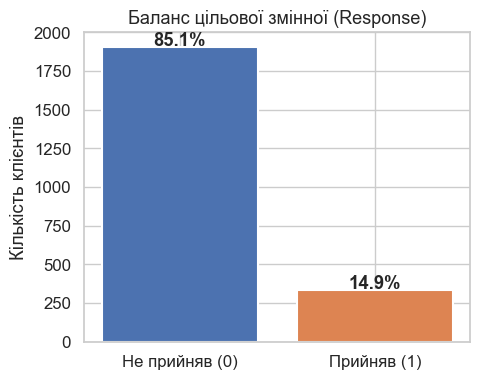

In [50]:
target_counts = df['Response'].value_counts()
target_pct = df['Response'].value_counts(normalize=True) * 100

print('Розподіл Response:')
print(pd.DataFrame({'count': target_counts, '%': target_pct.round(1)}))

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Не прийняв (0)', 'Прийняв (1)'],
       target_counts.values,
       color=PALETTE, edgecolor='white', linewidth=1.5)
for i, (v, p) in enumerate(zip(target_counts.values, target_pct.values)):
    ax.text(i, v + 10, f'{p:.1f}%', ha='center', fontweight='bold')
ax.set_title('Баланс цільової змінної (Response)', fontsize=13)
ax.set_ylabel('Кількість клієнтів')
plt.tight_layout()
plt.show()

In [51]:
statuses_to_find = ['Alone', 'YOLO', 'Absurd']

filtered_rows = df[df['Marital_Status'].isin(statuses_to_find)]

print(f"Знайдено {len(filtered_rows)} рядків:")
filtered_rows

Знайдено 7 рядків:


,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
103,492,1973,PhD,YOLO,48432.00,0,1,10/18/2012,3,322,3,50,4,3,42,5,7,1,6,8,0,0
104,11133,1973,PhD,YOLO,48432.00,0,1,10/18/2012,3,322,3,50,4,3,42,5,7,1,6,8,1,0
286,92,1988,Graduation,Alone,34176.00,1,0,12/5/2014,12,5,7,24,19,14,20,4,3,0,4,6,0,0
838,7660,1973,PhD,Alone,35860.00,1,1,5/19/2014,37,15,0,8,4,2,20,2,1,1,2,5,1,0
959,433,1958,Master,Alone,61331.00,1,1,10/3/2013,42,534,5,47,0,5,41,5,11,1,6,8,0,0
1068,4369,1957,Master,Absurd,65487.00,0,0,10/1/2014,48,240,67,500,199,0,163,3,3,5,6,2,0,0
1339,7734,1993,Graduation,Absurd,79244.00,0,0,12/19/2012,58,471,102,125,212,61,245,1,4,10,7,1,1,0


## Очищення даних

In [52]:
duplicates = df[df.duplicated(subset=df.columns.difference(["Id"]), keep=False)]
print("Кількість таких записів:", len(duplicates))
duplicates

Кількість таких записів: 358


,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
8,4047,1954,PhD,Married,65324.00,0,1,11/1/2014,0,384,0,102,21,32,5,3,6,2,9,4,0,0
9,9477,1954,PhD,Married,65324.00,0,1,11/1/2014,0,384,0,102,21,32,5,3,6,2,9,4,0,0
26,5430,1956,Graduation,Together,54450.00,1,1,9/14/2012,0,454,0,171,8,19,32,12,9,2,8,8,0,0
27,8432,1956,Graduation,Together,54450.00,1,1,9/14/2012,0,454,0,171,8,19,32,12,9,2,8,8,0,0
80,9888,1969,Graduation,Together,68695.00,0,0,6/25/2014,3,458,81,356,106,50,40,1,4,4,7,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2225,7212,1966,Graduation,Married,44794.00,0,1,8/6/2014,99,54,0,7,0,0,4,1,2,0,3,6,0,0
2229,2106,1974,2n Cycle,Married,20130.00,0,0,3/17/2014,99,0,6,3,7,6,12,1,1,0,3,8,0,0
2230,3363,1974,2n Cycle,Married,20130.00,0,0,3/17/2014,99,0,6,3,7,6,12,1,1,0,3,8,0,0
2231,8595,1973,Graduation,Widow,42429.00,0,1,11/2/2014,99,55,0,6,2,0,4,2,1,1,3,5,0,0


In [53]:
df_clean = df.copy()

df_clean = df_clean.drop_duplicates(subset=df_clean.columns.difference(["Id"]))

df_clean['Dt_Customer'] = pd.to_datetime(df_clean['Dt_Customer'], format='%m/%d/%Y')
snapshot_date = df_clean['Dt_Customer'].max() + pd.DateOffset(days=1)
print(f'Snapshot date: {snapshot_date.date()}')

current_year = 2014
df_clean['Age'] = current_year - df_clean['Year_Birth']

df_clean.dropna(inplace=True)
print(f'Розмір після dropna: {df_clean.shape}')

statuses_to_drop = ['Alone', 'YOLO', 'Absurd']

print(f'\nUnique Marital_Status до: {df_clean["Marital_Status"].unique()}')
print(f'Рядків до: {len(df_clean)}')

df_clean = df_clean[~df_clean['Marital_Status'].isin(statuses_to_drop)]

print(f'Unique Marital_Status після: {df_clean["Marital_Status"].unique()}')
print(f'Рядків після: {len(df_clean)}')
df_clean

Snapshot date: 2014-12-07
Розмір після dropna: (2034, 23)

Unique Marital_Status до: ['Divorced' 'Single' 'Married' 'Together' 'Widow' 'YOLO' 'Alone' 'Absurd']
Рядків до: 2034
Unique Marital_Status після: ['Divorced' 'Single' 'Married' 'Together' 'Widow']
Рядків після: 2027


,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age
0,1826,1970,Graduation,Divorced,84835.00,0,0,2014-06-16,0,189,104,379,111,189,218,1,4,4,6,1,1,0,44
1,1,1961,Graduation,Single,57091.00,0,0,2014-06-15,0,464,5,64,7,0,37,1,7,3,7,5,1,0,53
2,10476,1958,Graduation,Married,67267.00,0,1,2014-05-13,0,134,11,59,15,2,30,1,3,2,5,2,0,0,56
3,1386,1967,Graduation,Together,32474.00,1,1,2014-11-05,0,10,0,1,0,0,0,1,1,0,2,7,0,0,47
4,5371,1989,Graduation,Single,21474.00,1,0,2014-08-04,0,6,16,24,11,0,34,2,3,1,2,7,1,0,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476.00,0,1,2013-07-03,99,372,18,126,47,48,78,2,5,2,11,4,0,0,38
2236,5263,1977,2n Cycle,Married,31056.00,1,0,2013-01-22,99,5,10,13,3,8,16,1,1,0,3,8,0,0,37
2237,22,1976,Graduation,Divorced,46310.00,1,0,2012-03-12,99,185,2,88,15,5,14,2,6,1,5,8,0,0,38
2238,528,1978,Graduation,Married,65819.00,0,0,2012-11-29,99,267,38,701,149,165,63,1,5,4,10,3,0,0,36


## Розподіли

### Числові змінні

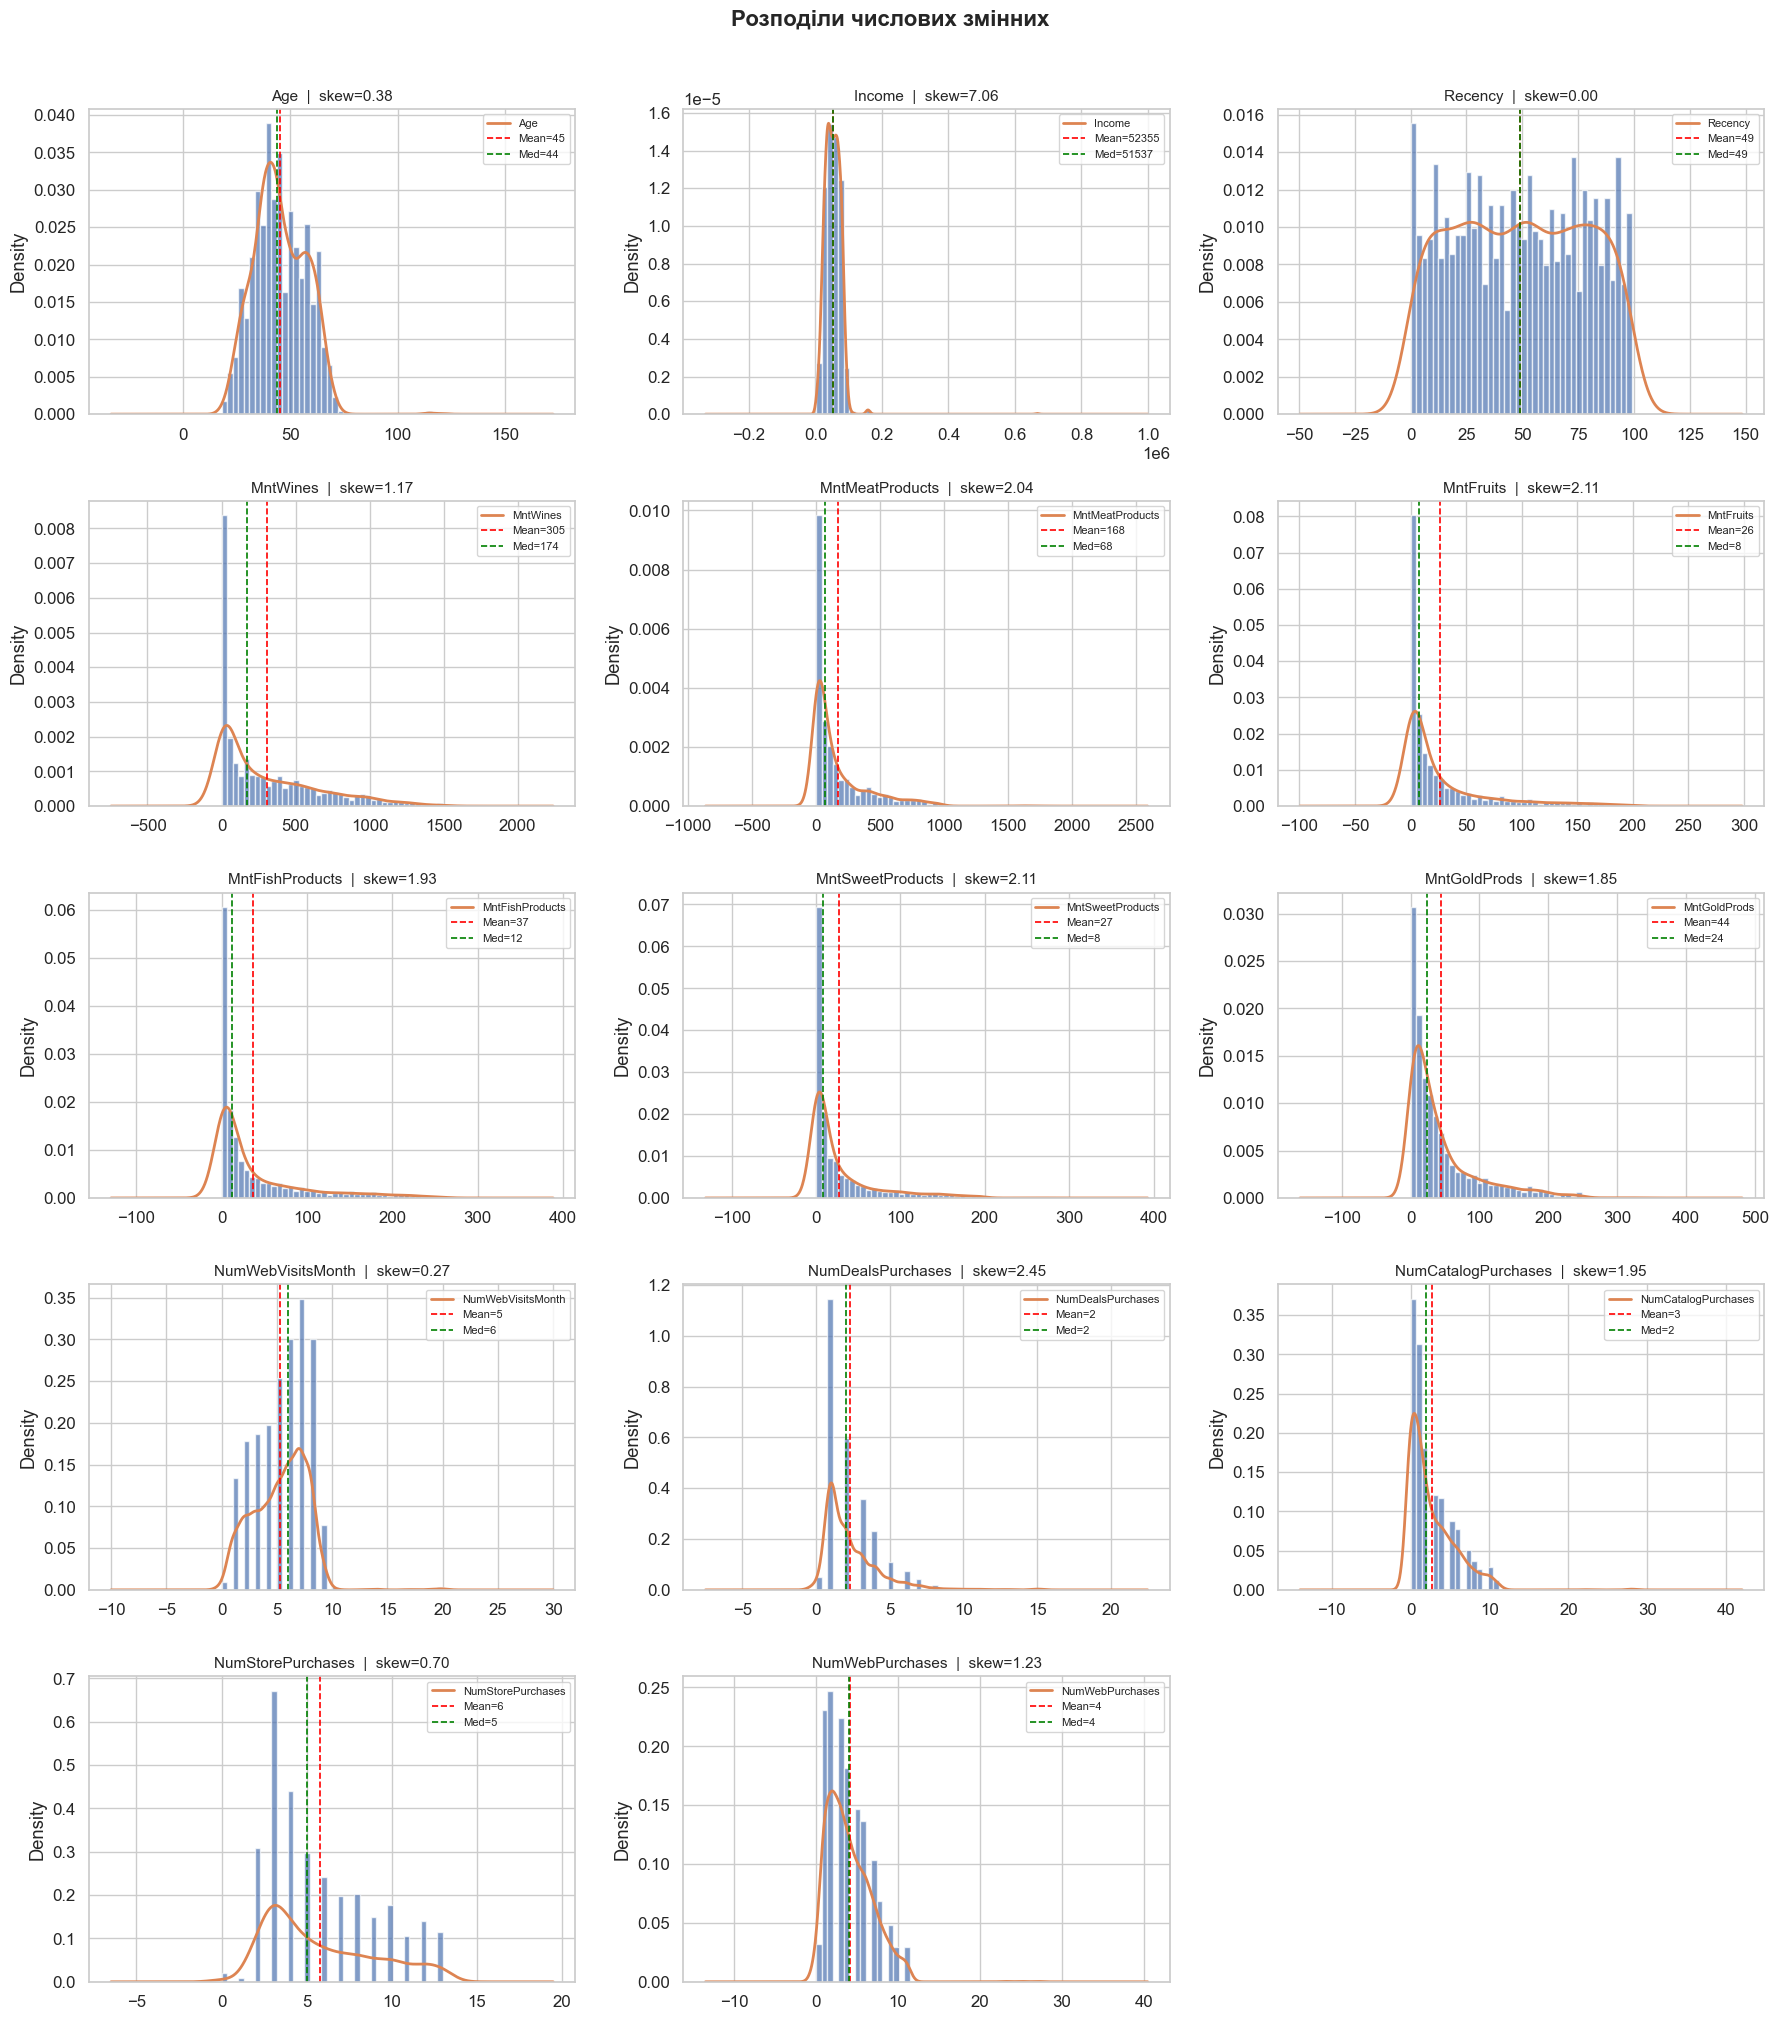

In [54]:
num_cols = ['Age', 'Income', 'Recency',
            'MntWines', 'MntMeatProducts', 'MntFruits',
            'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
            'NumWebVisitsMonth', 'NumDealsPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebPurchases']

n = len(num_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    data = df_clean[col].dropna()
    # Гістограма + KDE
    ax.hist(data, bins=40, color='#4C72B0', alpha=0.7, edgecolor='white', density=True)
    data.plot.kde(ax=ax, color='#DD8452', linewidth=2)
    ax.axvline(data.mean(),   color='red',   linestyle='--', linewidth=1.2, label=f'Mean={data.mean():.0f}')
    ax.axvline(data.median(), color='green', linestyle='--', linewidth=1.2, label=f'Med={data.median():.0f}')
    skew = data.skew()
    ax.set_title(f'{col}  |  skew={skew:.2f}', fontsize=11)
    ax.legend(fontsize=8)
    ax.set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Розподіли числових змінних', fontsize=16, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

### Категорійні змінні

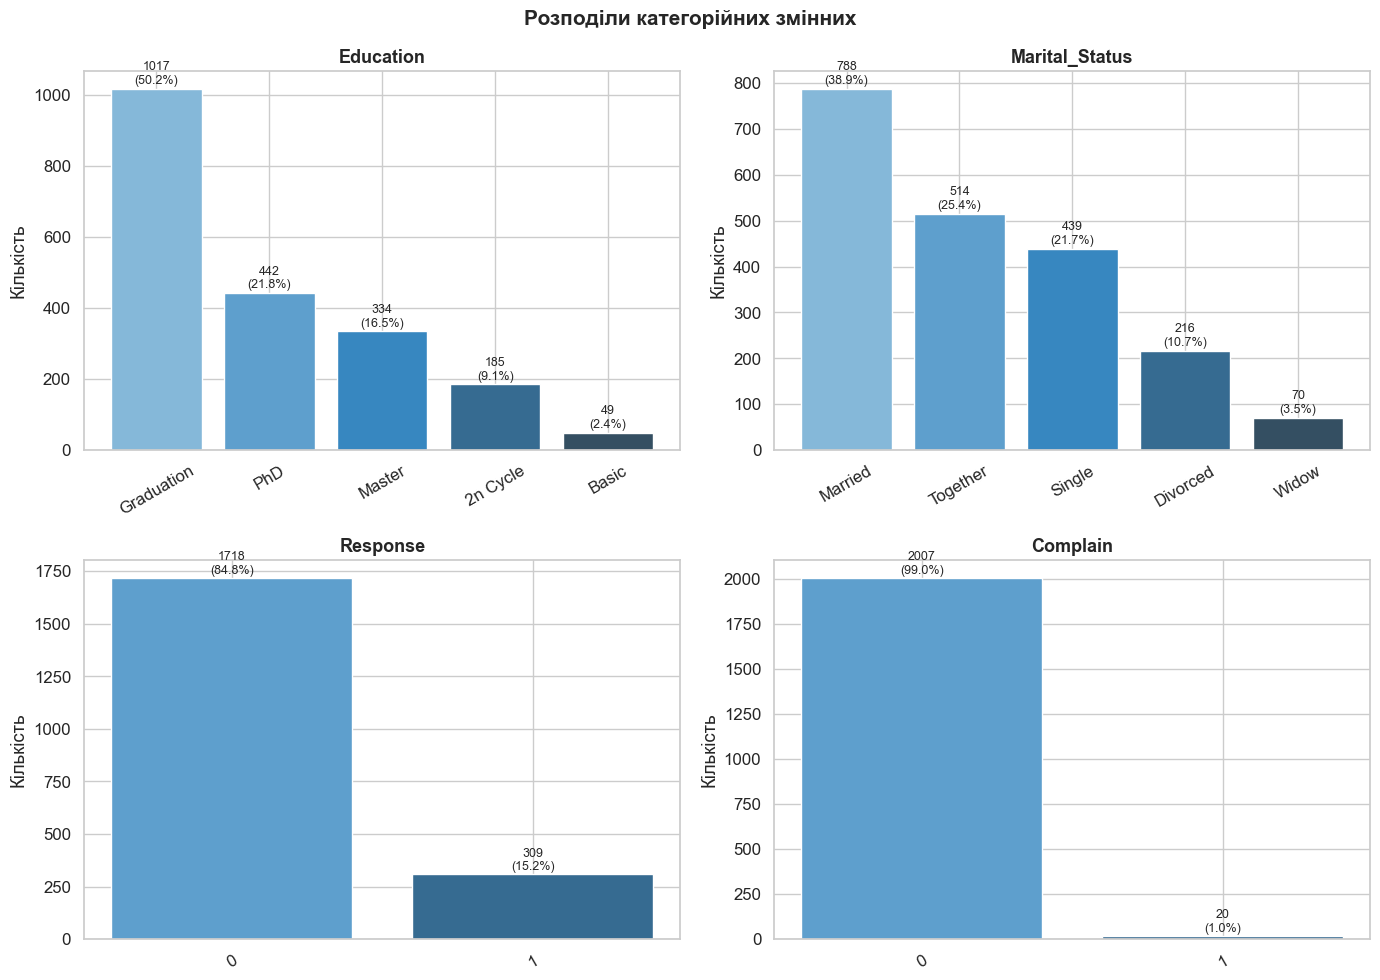

In [55]:
cat_cols = ['Education', 'Marital_Status', 'Response', 'Complain']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = df_clean[col].value_counts()
    colors = sns.color_palette('Blues_d', len(vc))
    bars = axes[i].bar(vc.index.astype(str), vc.values, color=colors, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2.,
                     h + 5, f'{h}\n({h/len(df_clean)*100:.1f}%)',
                     ha='center', va='bottom', fontsize=9)
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Кількість')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Розподіли категорійних змінних', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

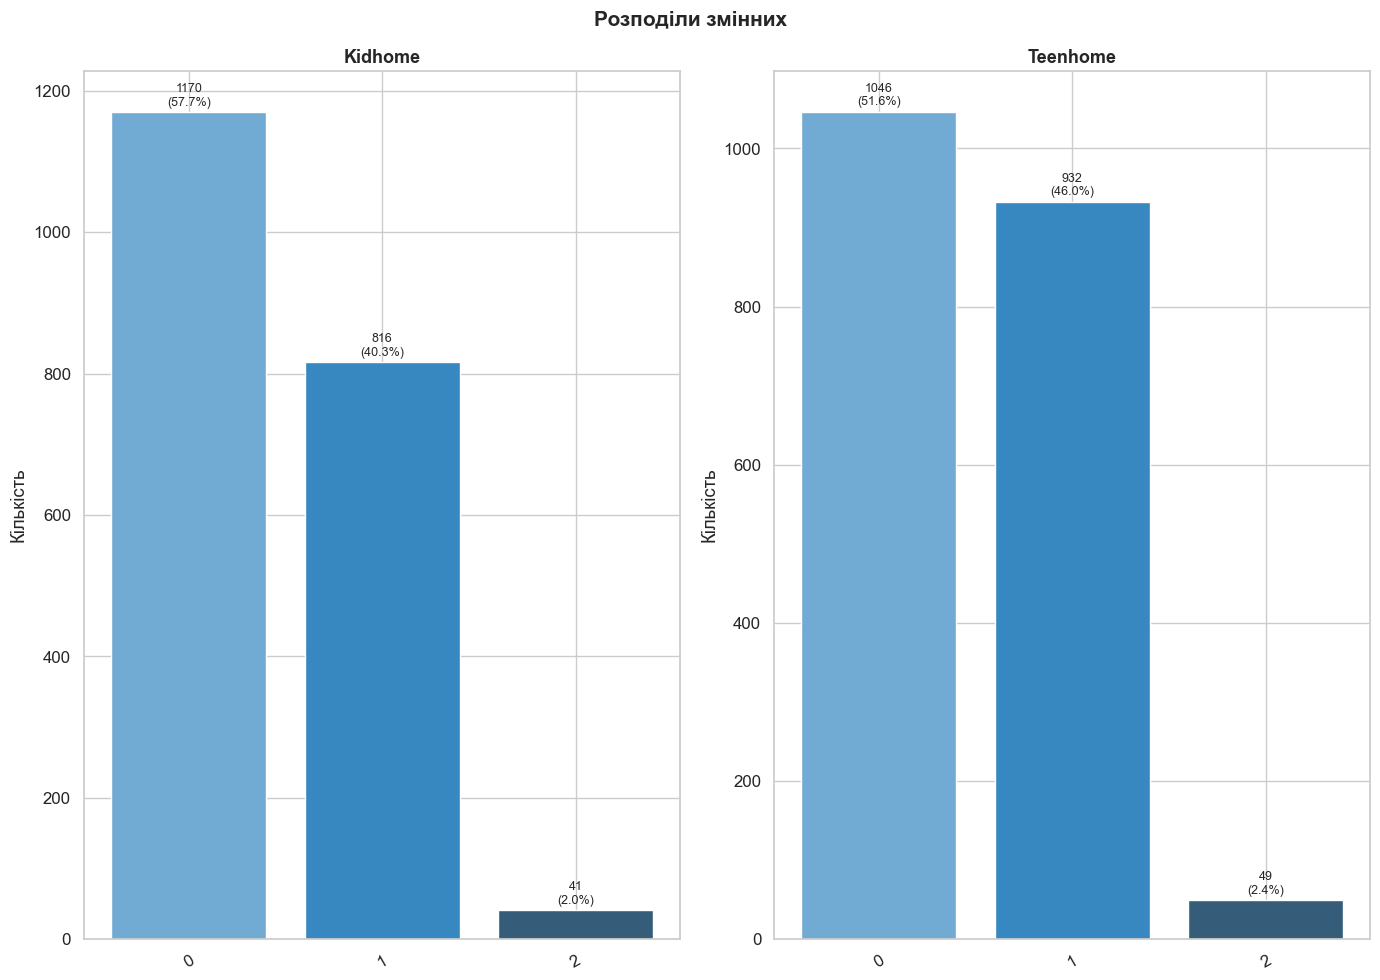

In [56]:
count_cols = ['Kidhome', 'Teenhome']

fig, axes = plt.subplots(1, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(count_cols):
    vc = df_clean[col].value_counts()
    colors = sns.color_palette('Blues_d', len(vc))
    bars = axes[i].bar(vc.index.astype(str), vc.values, color=colors, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2.,
                     h + 5, f'{h}\n({h/len(df_clean)*100:.1f}%)',
                     ha='center', va='bottom', fontsize=9)
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Кількість')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Розподіли змінних', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Outlier Detection

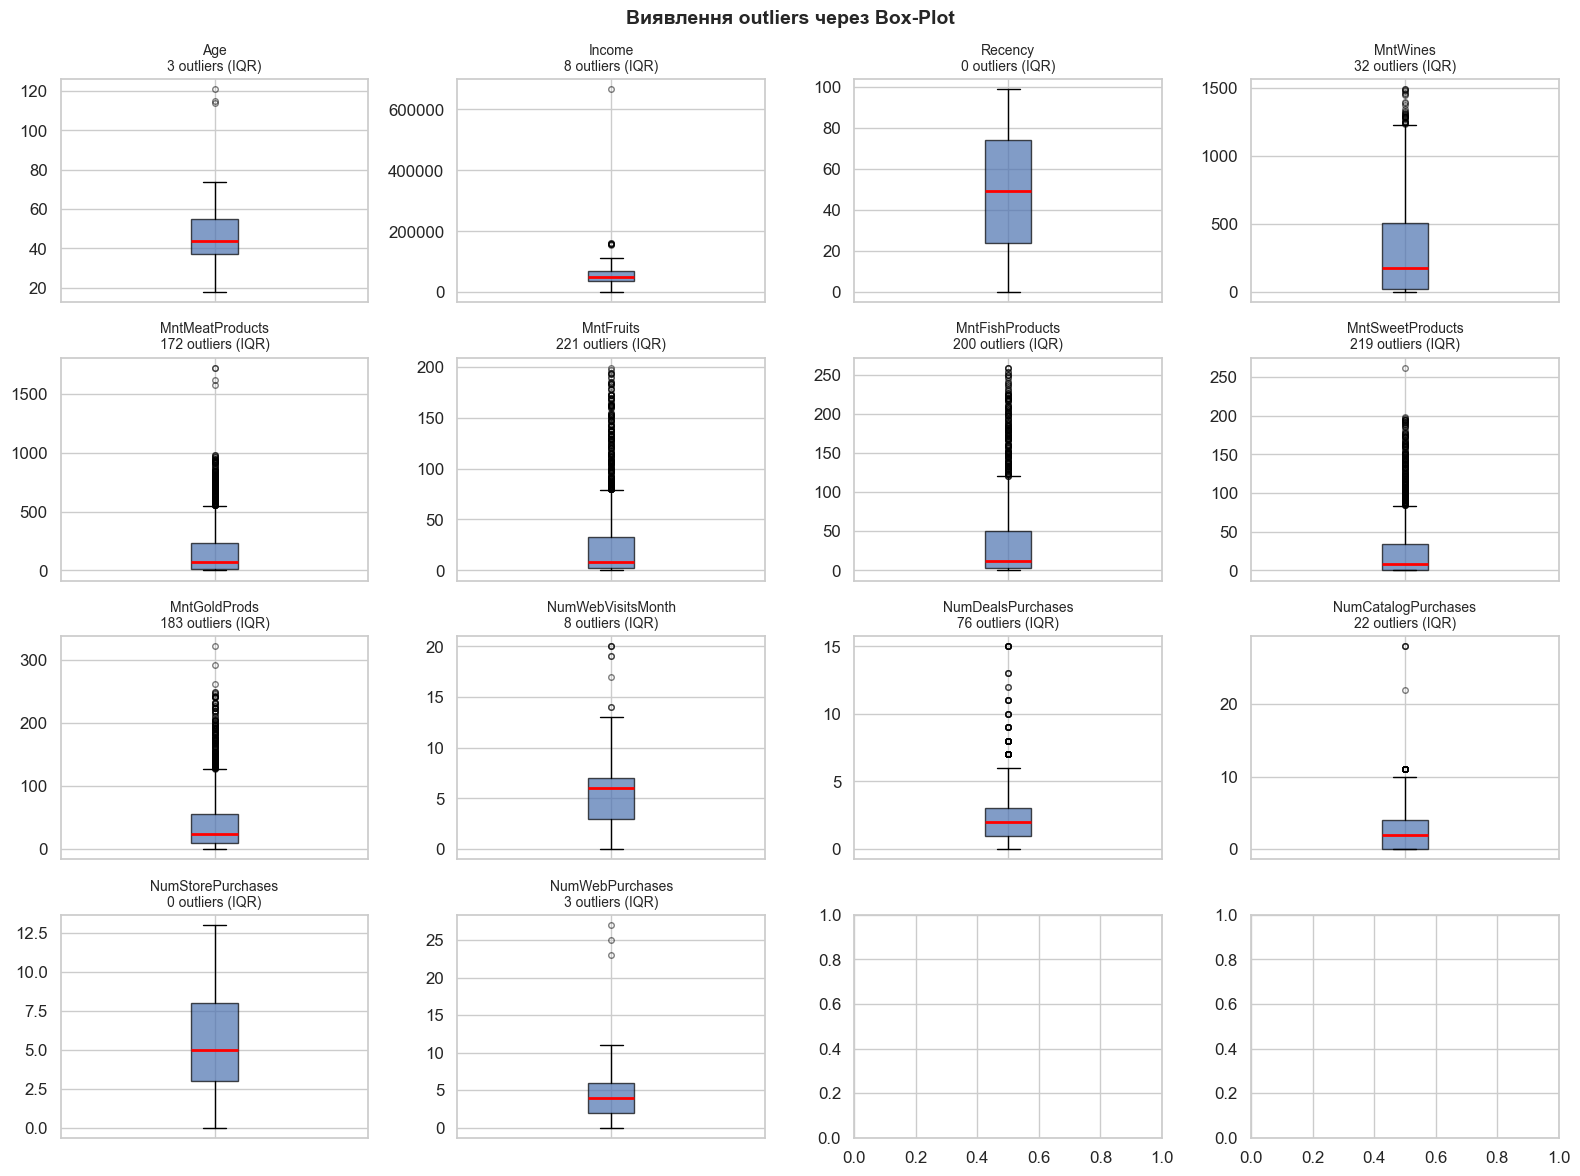

In [57]:
outlier_cols = ['Age', 'Income', 'Recency',
            'MntWines', 'MntMeatProducts', 'MntFruits',
            'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
            'NumWebVisitsMonth', 'NumDealsPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebPurchases']

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    ax = axes[i]
    data = df_clean[col].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops={'facecolor': '#4C72B0', 'alpha': 0.7},
               medianprops={'color': 'red', 'linewidth': 2},
               flierprops={'alpha': 0.5, 'markersize': 4})

    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    ax.set_title(f'{col}\n{n_outliers} outliers (IQR)', fontsize=10)
    ax.set_xticklabels([])

plt.suptitle('Виявлення outliers через Box-Plot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [58]:
def iqr_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    mask = (series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)
    return mask.sum(), mask.mean() * 100, Q1 - 1.5*IQR, Q3 + 1.5*IQR


rows = []
for col in outlier_cols:
    n, pct, lower, upper = iqr_outliers(df_clean[col].dropna())
    rows.append({'Колонка': col, 'N outliers': n, '% outliers': f'{pct:.1f}%',
                 'Lower fence': f'{lower:.1f}', 'Upper fence': f'{upper:.1f}'})

outlier_df = pd.DataFrame(rows)
print(outlier_df.to_string(index=False))

print("\n" + "="*60)
print("ПОВНІ ЗАПИСИ З АУТЛАЄРАМИ ПО КОЛОНКАХ")
print("="*60)

outlier_index_sets = {}

for col in outlier_cols:
    series = df_clean[col].dropna()
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    mask = (series < lower) | (series > upper)
    outlier_idx = series[mask].index
    outlier_index_sets[col] = set(outlier_idx)

    if outlier_idx.empty:
        continue

    print(f"\n📌 Колонка: '{col}'  |  межі: [{lower:.1f}, {upper:.1f}]  |  аутлаєрів: {len(outlier_idx)}")
    display(df_clean.loc[outlier_idx].sort_values(col))


print("\n" + "="*60)
print("АНАЛІЗ ПЕРЕТИНУ АУТЛАЄРІВ")
print("="*60)

all_outlier_indices = pd.Series(0, index=df_clean.index)
for col, idx_set in outlier_index_sets.items():
    all_outlier_indices.loc[list(idx_set)] += 1

overlap_counts = all_outlier_indices.value_counts().sort_index()
for n_cols, count in overlap_counts.items():
    if n_cols == 0:
        continue
    print(f"  Аутлаєр одночасно у {n_cols} колонці(-ах): {count} записів")

multi_outlier_idx = all_outlier_indices[all_outlier_indices >= 2].index
if len(multi_outlier_idx) > 0:
    print(f"\n Записи-аутлаєри одразу у 2+ колонках ({len(multi_outlier_idx)} шт.):")
    display(df_clean.loc[multi_outlier_idx])

            Колонка  N outliers % outliers Lower fence Upper fence
                Age           3       0.1%        10.0        82.0
             Income           8       0.4%    -14130.5    118169.5
            Recency           0       0.0%       -51.0       149.0
           MntWines          32       1.6%      -701.5      1230.5
    MntMeatProducts         172       8.5%      -305.0       551.0
          MntFruits         221      10.9%       -44.5        79.5
    MntFishProducts         200       9.9%       -67.5       120.5
   MntSweetProducts         219      10.8%       -48.5        83.5
       MntGoldProds         183       9.0%       -61.5       126.5
  NumWebVisitsMonth           8       0.4%        -3.0        13.0
  NumDealsPurchases          76       3.7%        -2.0         6.0
NumCatalogPurchases          22       1.1%        -6.0        10.0
  NumStorePurchases           0       0.0%        -4.5        15.5
    NumWebPurchases           3       0.1%        -4.0        

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age
2233,7829,1900,2n Cycle,Divorced,36640.00,1,0,2013-09-26,99,15,6,8,7,4,25,1,2,1,2,5,0,1,114
827,1150,1899,PhD,Together,83532.00,0,0,2013-09-26,36,755,144,562,104,64,224,1,4,6,4,1,0,0,115
513,11004,1893,2n Cycle,Single,60182.00,0,1,2014-05-17,23,8,0,5,7,0,2,1,1,0,2,4,0,0,121



📌 Колонка: 'Income'  |  межі: [-14130.5, 118169.5]  |  аутлаєрів: 8


,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age
1826,5555,1975,Graduation,Divorced,153924.00,0,0,2014-07-02,81,1,1,1,1,1,1,0,0,0,0,0,0,0,39
1925,11181,1949,PhD,Married,156924.00,0,0,2013-08-29,85,2,1,2,1,1,1,0,0,0,0,0,0,0,65
325,4931,1977,Graduation,Together,157146.00,0,0,2013-04-29,13,1,0,1725,2,1,1,0,0,28,0,1,0,0,37
2204,8475,1973,PhD,Married,157243.00,0,1,2014-01-03,98,20,2,1582,1,2,1,15,0,22,0,0,0,0,41
853,5336,1971,Master,Together,157733.00,1,0,2013-04-06,37,39,1,9,2,0,8,0,1,0,1,1,0,0,43
497,1501,1982,PhD,Married,160803.00,0,0,2012-04-08,21,55,16,1622,17,3,4,15,0,28,1,0,0,0,32
731,1503,1976,PhD,Together,162397.00,1,1,2013-03-06,31,85,1,16,2,1,2,0,0,0,1,1,0,0,38
527,9432,1977,Graduation,Together,666666.00,1,0,2013-02-06,23,9,14,18,8,1,12,4,3,1,3,6,0,0,37



📌 Колонка: 'MntWines'  |  межі: [-701.5, 1230.5]  |  аутлаєрів: 32


...

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age
292,2324,1972,Graduation,Together,77044.00,0,1,2013-10-27,12,625,38,242,50,34,76,2,7,11,11,4,0,0,42
399,5718,1950,Graduation,Married,80763.00,0,0,2013-08-15,17,674,168,108,192,42,231,1,5,11,6,3,1,0,64
434,10102,1966,Graduation,Widow,79946.00,0,0,2014-12-05,19,395,183,565,166,141,28,1,5,11,5,3,0,0,48
588,7627,1975,Master,Married,92163.00,0,0,2012-12-12,25,817,183,797,106,163,20,0,5,11,5,2,1,0,39
678,10524,1963,Master,Divorced,49476.00,0,1,2013-06-20,29,386,23,95,54,41,196,4,2,11,5,2,0,0,51
661,4299,1960,Graduation,Together,70971.00,0,1,2012-09-21,28,1001,17,572,93,125,17,7,11,11,5,7,1,0,54
911,6246,1953,Graduation,Single,73892.00,0,0,2013-11-13,40,703,102,601,0,58,43,1,3,11,8,1,1,0,61
803,8908,1959,Graduation,Married,87195.00,0,0,2014-08-05,35,217,76,690,50,26,38,1,3,11,5,1,1,0,55
1489,9058,1955,Graduation,Widow,79800.00,0,0,2012-09-23,65,1060,21,530,32,0,224,1,5,11,5,3,1,0,59
1404,1763,1988,Graduation,Together,87679.00,0,0,2013-07-27,62,1259,172,815,97,148,33,1,7,11,10,4,1,0,26



📌 Колонка: 'NumWebPurchases'  |  межі: [-4.0, 12.0]  |  аутлаєрів: 3


,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age
2063,6237,1966,PhD,Single,7144.00,0,2,2013-07-12,92,81,4,33,5,2,291,0,23,1,1,0,0,0,48
14,10311,1969,Graduation,Married,4428.00,0,1,2013-05-10,0,16,4,12,2,4,321,0,25,0,0,1,0,0,45
210,4619,1945,PhD,Single,113734.00,0,0,2014-05-28,9,6,2,3,1,262,3,0,27,0,0,1,0,0,69



АНАЛІЗ ПЕРЕТИНУ АУТЛАЄРІВ
  Аутлаєр одночасно у 1 колонці(-ах): 328 записів
  Аутлаєр одночасно у 2 колонці(-ах): 177 записів
  Аутлаєр одночасно у 3 колонці(-ах): 99 записів
  Аутлаєр одночасно у 4 колонці(-ах): 37 записів
  Аутлаєр одночасно у 5 колонці(-ах): 4 записів

 Записи-аутлаєри одразу у 2+ колонках (317 шт.):


,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age
0,1826,1970,Graduation,Divorced,84835.00,0,0,2014-06-16,0,189,104,379,111,189,218,1,4,4,6,1,1,0,44
5,7348,1958,PhD,Single,71691.00,0,0,2014-03-17,0,336,130,411,240,32,43,1,4,7,5,2,1,0,56
14,10311,1969,Graduation,Married,4428.00,0,1,2013-05-10,0,16,4,12,2,4,321,0,25,0,0,1,0,0,45
31,9264,1986,Graduation,Married,79529.00,0,0,2014-04-27,1,423,42,706,73,197,197,1,4,8,9,2,0,0,28
36,2681,1984,2n Cycle,Married,65370.00,0,0,2013-01-08,1,71,22,112,138,89,29,1,2,3,13,1,0,0,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2219,5687,1980,Graduation,Divorced,81702.00,0,0,2012-09-23,98,563,50,774,28,31,187,1,7,7,12,3,0,0,34
2223,2831,1976,Graduation,Together,78416.00,0,1,2014-06-27,99,453,38,279,188,38,183,2,7,7,10,3,0,0,38
2226,1743,1974,Graduation,Single,69719.00,0,0,2014-05-26,99,273,86,208,177,14,43,1,2,3,5,1,0,0,40
2238,528,1978,Graduation,Married,65819.00,0,0,2012-11-29,99,267,38,701,149,165,63,1,5,4,10,3,0,0,36


In [59]:
print('Z-score outliers (|z| > 3):')
for col in outlier_cols:
    z = np.abs(stats.zscore(df_clean[col].dropna()))
    n = (z > 3).sum()
    print(f'  {col:30s}: {n}')

Z-score outliers (|z| > 3):
  Age                           : 3
  Income                        : 8
  Recency                       : 0
  MntWines                      : 13
  MntMeatProducts               : 34
  MntFruits                     : 60
  MntFishProducts               : 52
  MntSweetProducts              : 54
  MntGoldProds                  : 42
  NumWebVisitsMonth             : 9
  NumDealsPurchases             : 29
  NumCatalogPurchases           : 4
  NumStorePurchases             : 0
  NumWebPurchases               : 3


In [60]:
Q1, Q3 = df_clean['Age'].quantile(0.25), df_clean['Age'].quantile(0.75)
IQR = Q3 - Q1
age_mask = (df_clean['Age'] >= Q1 - 1.5*IQR) & (df_clean['Age'] <= Q3 + 1.5*IQR)

income_mask = df_clean['Income'] != 666666.00

df_clean = df_clean[age_mask & income_mask]

print(f"Залишилось записів: {len(df_clean)}")
print(f"Видалено по Age:    {(~age_mask).sum()}")
print(f"Видалено по Income: {(~income_mask).sum()}")

Залишилось записів: 2023
Видалено по Age:    3
Видалено по Income: 1


### Числові змінні vs Response

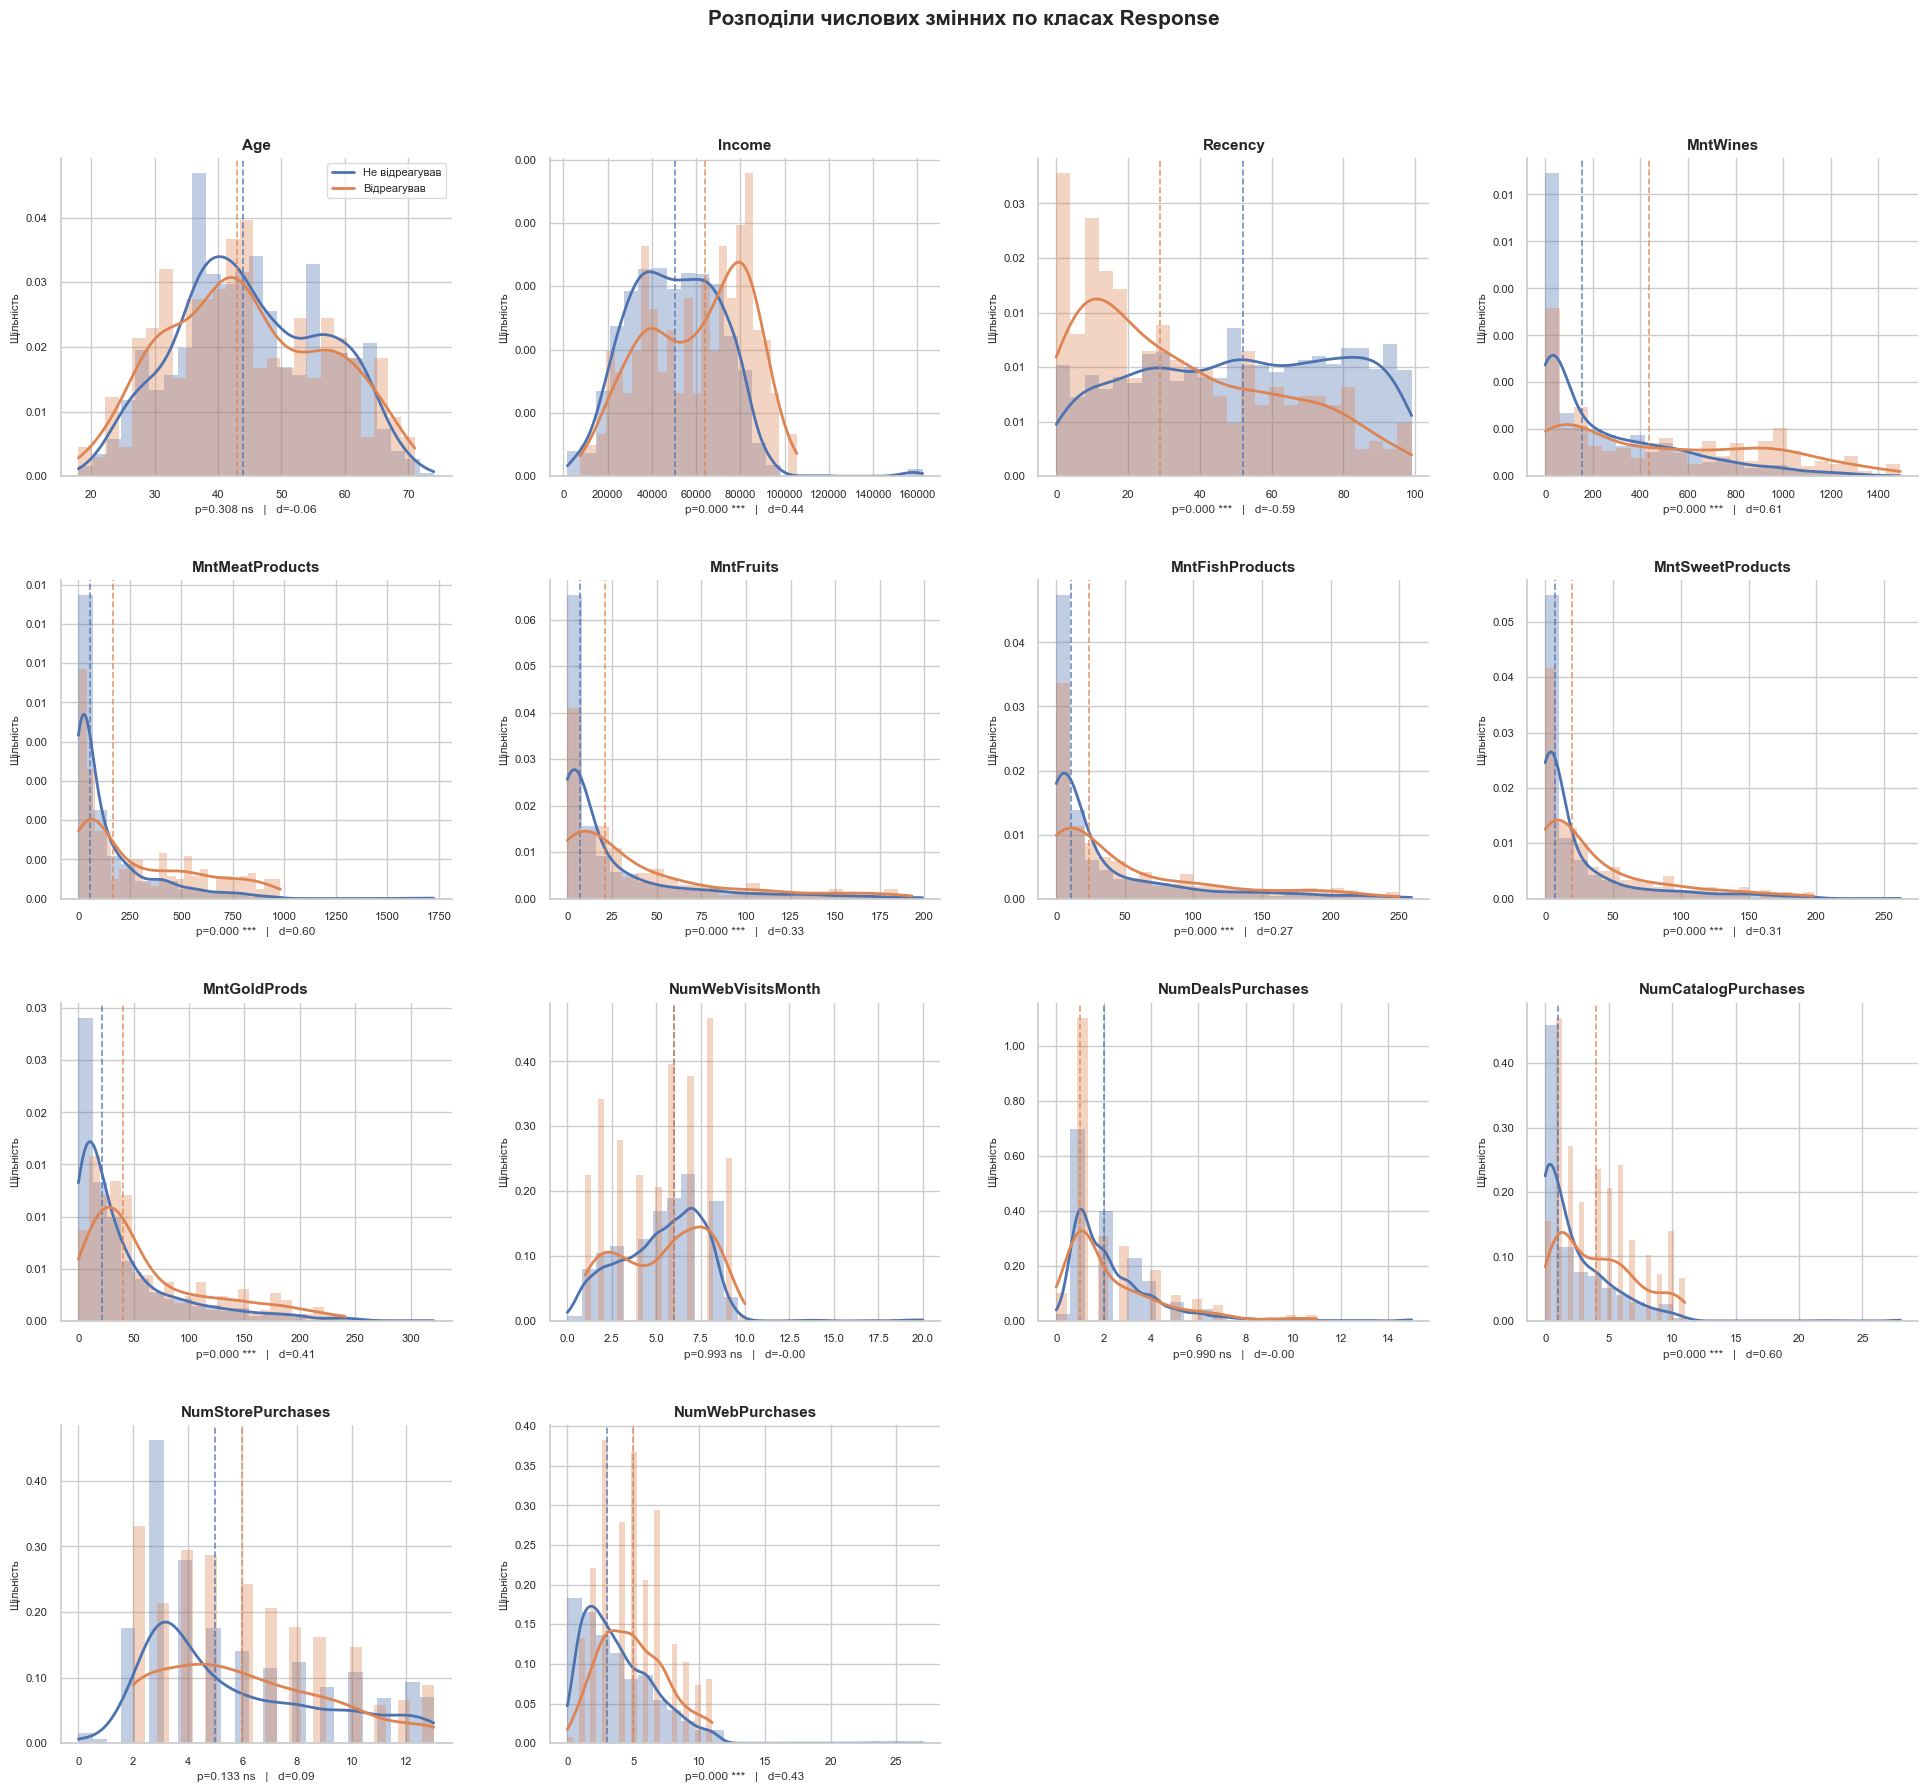

In [61]:
import matplotlib.ticker as mticker
import numpy as np
from scipy import stats
from scipy.stats import gaussian_kde


bivar_num = ['Age', 'Income', 'Recency',
             'MntWines', 'MntMeatProducts', 'MntFruits',
             'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
             'NumWebVisitsMonth', 'NumDealsPurchases', 'NumCatalogPurchases',
             'NumStorePurchases', 'NumWebPurchases']

PALETTE = ['#4C72B0', '#DD8452']
LABELS = {0: 'Не відреагував', 1: 'Відреагував'}

fig, axes = plt.subplots(4, 4, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(bivar_num):
    ax = axes[i]

    g0 = df_clean[df_clean['Response'] == 0][col].dropna()
    g1 = df_clean[df_clean['Response'] == 1][col].dropna()

    # --- Гістограма + KDE поверх неї ---
    for data, color, label in zip([g0, g1], PALETTE, LABELS.values()):
        ax.hist(data, bins=25, alpha=0.35, color=color, density=True,
                edgecolor='none')

        # KDE-крива для чіткішого порівняння форми
        kde = gaussian_kde(data, bw_method='scott')
        x_range = np.linspace(data.min(), data.max(), 300)
        ax.plot(x_range, kde(x_range), color=color, linewidth=2, label=label)

        # Медіана — вертикальна пунктирна лінія
        ax.axvline(data.median(), color=color, linestyle='--',
                   linewidth=1.2, alpha=0.8)

    # --- t-test + розмір ефекту (Cohen's d) ---
    t, p = stats.ttest_ind(g0, g1)
    pooled_std = np.sqrt((g0.std()**2 + g1.std()**2) / 2)
    cohens_d = (g1.mean() - g0.mean()) / pooled_std if pooled_std > 0 else 0

    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))

    ax.set_title(col, fontsize=11, fontweight='bold', pad=6)

    # p-value + Cohen's d в підписі осі X
    ax.set_xlabel(
        f'p={p:.3f} {sig}   |   d={cohens_d:.2f}',
        fontsize=8.5, color='#333333'
    )
    ax.set_ylabel('Щільність', fontsize=8)

    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    if i == 0:
        ax.legend(fontsize=8, framealpha=0.7, loc='upper right')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Розподіли числових змінних по класах Response',
    fontsize=15, fontweight='bold', y=1.01
)
plt.tight_layout(pad=2.5)
plt.show()

# Аналіз фіч по розподілах (Response)

---

## Слабкі фічі

**Age** — `p=0.308 ns | d=-0.06`
Криві майже ідентичні, різниця випадкова. Вік клієнта не впливає на рішення відреагувати.

**NumWebVisitsMonth** — `p=0.993 ns | d=0.00`
Повне перекриття кривих. Кількість візитів на сайт абсолютно не розділяє класи.

**NumDealsPurchases** — `p=0.990 ns | d=0.00`
Те саме — криві зливаються. Купівлі зі знижкою не корелюють з відгуком на кампанію. Цікавий інсайт: клієнти, що полюють за знижками — окремий сегмент, не цільова аудиторія кампанії.

**NumStorePurchases** — `p=0.133 ns | d=0.09`
Слабкий, незначимий ефект. Покупки в магазині не розрізняють групи.

---

## Середні фічі

**MntFruits** — `p=0.000 *** | d=0.33`
Статистично значима, але малий ефект. Ті хто відреагував витрачають трохи більше на фрукти. Корисна, але не ключова.

**MntFishProducts** — `p=0.000 *** | d=0.27`
Схожа ситуація — помаранчева крива зміщена вправо, але перекриття велике.

**MntSweetProducts** — `p=0.000 *** | d=0.31`
Невеликий зсув на користь тих хто відреагував. Разом з іншими Mnt-фічами може давати корисний сигнал.

**MntGoldProds** — `p=0.000 *** | d=0.41`
Середній ефект. Ті хто відреагував купують більше золотих товарів — можливо це більш преміальний сегмент.

---

## Сильні фічі

**Income** — `p=0.000 *** | d=0.44`
Помаранчева крива зміщена вправо (~60–80k vs ~50–60k). Клієнти з вищим доходом значно частіше відгукуються. Важлива фіча.

**Recency** — `p=0.000 *** | d=-0.59`
Негативний d — ті хто відреагував мають менший Recency (купували нещодавно). Синя крива зміщена вправо. Чітке розділення: активні клієнти реагують краще. Одна з найсильніших фіч.

**MntWines** — `p=0.000 *** | d=0.61`
Помаранчева крива має довший хвіст вправо. Ті хто відреагував витрачають суттєво більше на вино. Сильний предиктор.

**MntMeatProducts** — `p=0.000 *** | d=0.60`
Аналогічно — значне зміщення у відреагувавших. М'ясо і вино разом можуть відображати загальний преміальний стиль споживання.

**NumCatalogPurchases** — `p=0.000 *** | d=0.60`
Дуже сильна фіча. Помаранчева крива явно зміщена вправо. Клієнти що купують через каталог набагато частіше відгукуються — це найбільш лояльний канал.

**NumWebPurchases** — `p=0.000 *** | d=0.43`
Середньо-сильна. Активніші онлайн-покупці краще реагують на кампанії.

---

## Підсумкове ранжування для моделі

| Пріоритет | Фічі |
|---|---|
| Топ — залишити обов'язково | `Recency`, `MntWines`, `MntMeatProducts`, `NumCatalogPurchases` |
| Середні — залишити | `Income`, `MntGoldProds`, `NumWebPurchases`, `MntFruits`, `MntFishProducts`, `MntSweetProducts` |
| Слабкі — розглянути видалення | `Age`, `NumWebVisitsMonth`, `NumDealsPurchases`, `NumStorePurchases` |

> **Головний профіль клієнта що відреагує:** високий дохід, купував нещодавно, витрачає на вино та м'ясо, активно користується каталогом - це **преміальний лояльний покупець**, а не мисливець за знижками.

In [62]:
# ── Середні значення за Response ─────────────────────────────────
means = df_clean.groupby('Response')[bivar_num].mean().T
means.columns = ['Response=0 (Відмова)', 'Response=1 (Прийняв)']
means['Різниця (%)'] = ((means['Response=1 (Прийняв)'] - means['Response=0 (Відмова)'])
                         / means['Response=0 (Відмова)'] * 100).round(1)
print(means.to_string())

                     Response=0 (Відмова)  Response=1 (Прийняв)  Різниця (%)
Age                                 45.22                 44.49        -1.60
Income                           50566.44              60210.00        19.10
Recency                             51.44                 34.96       -32.00
MntWines                           271.21                495.78        82.80
MntMeatProducts                    144.75                296.90       105.10
MntFruits                           24.11                 38.18        58.40
MntFishProducts                     35.02                 50.41        43.90
MntSweetProducts                    25.14                 38.70        53.90
MntGoldProds                        40.29                 62.18        54.30
NumWebVisitsMonth                    5.32                  5.32        -0.00
NumDealsPurchases                    2.33                  2.33        -0.10
NumCatalogPurchases                  2.40                  4.17        73.70

### Категорійні змінні vs Response

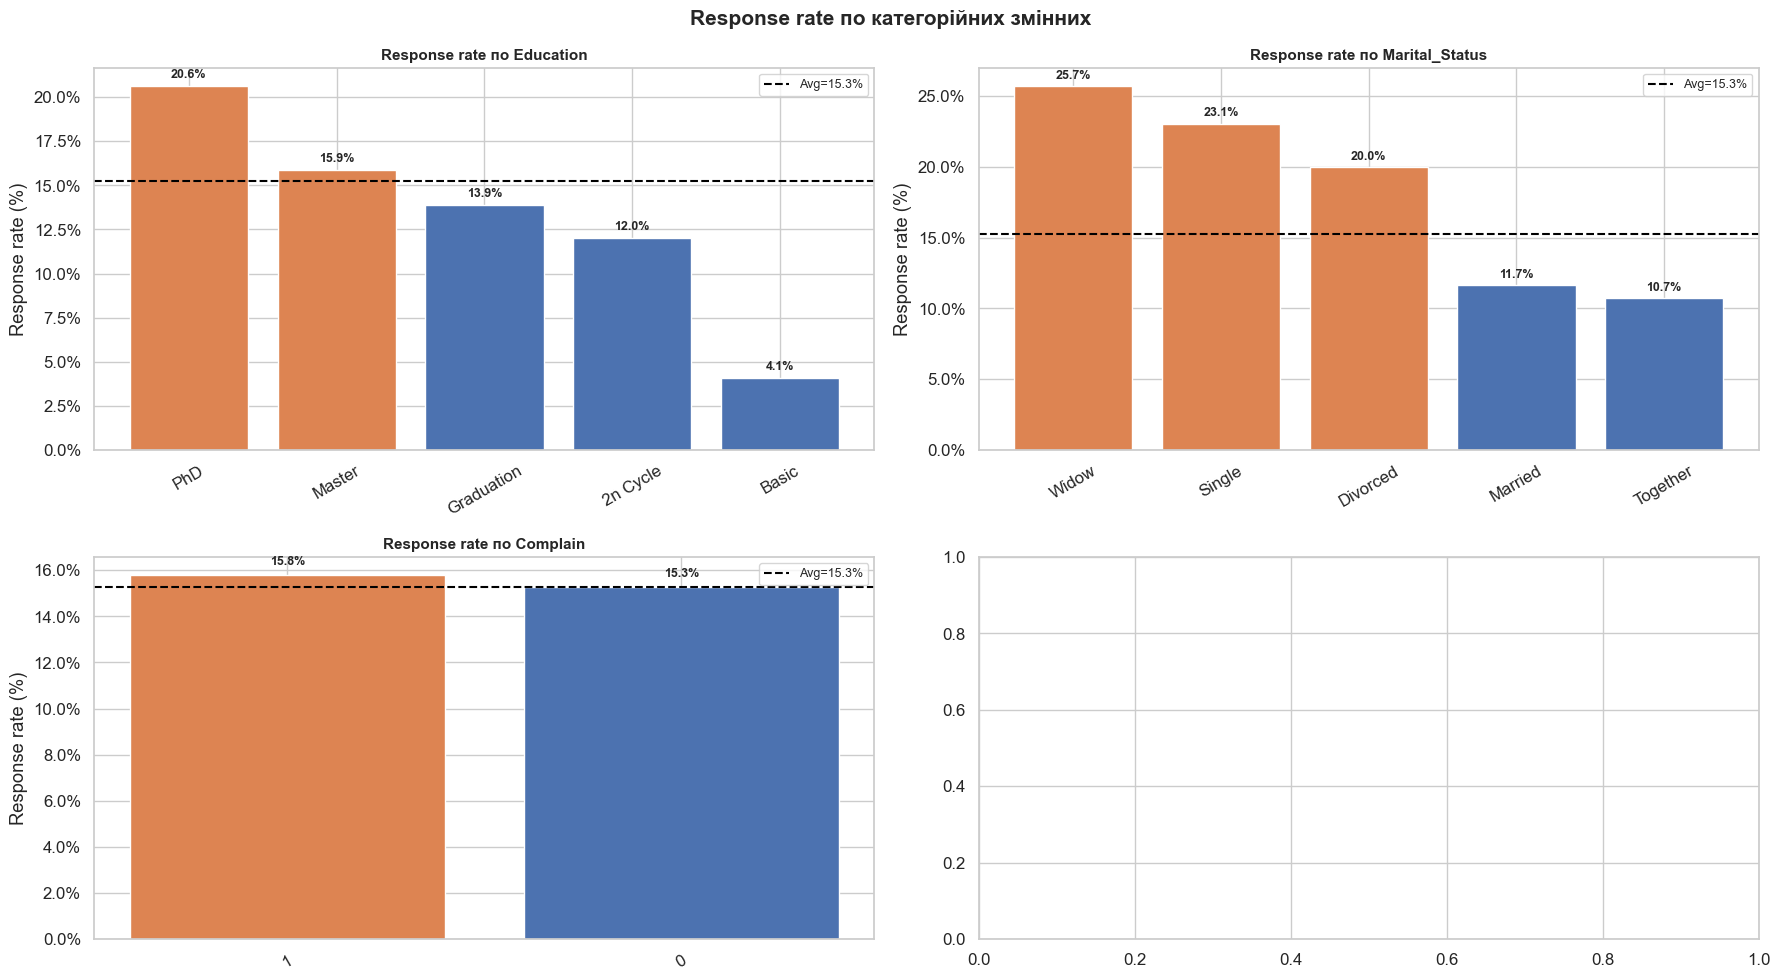

In [63]:
cat_target = ['Education', 'Marital_Status', 'Complain']

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_target):
    ax = axes[i]
    ct = df_clean.groupby(col)['Response'].mean().sort_values(ascending=False)
    colors = [PALETTE[1] if v > df_clean['Response'].mean() else PALETTE[0] for v in ct.values]
    bars = ax.bar(ct.index.astype(str), ct.values * 100, color=colors, edgecolor='white')
    ax.axhline(df_clean['Response'].mean() * 100, color='black',
               linestyle='--', linewidth=1.5, label=f'Avg={df_clean["Response"].mean()*100:.1f}%')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.3,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(f'Response rate по {col}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Response rate (%)')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('Response rate по категорійних змінних', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Education

| Рівень освіти | Response rate | vs Avg |
|---|---|---|
| PhD | 20.6% | ▲ +5.3% |
| Master | 15.9% | ▲ +0.6% |
| Graduation | 13.9% | ▼ -1.4% |
| 2n Cycle | 12.0% | ▼ -3.3% |
| Basic | 4.1% | ▼ -11.2% |

Чіткий лінійний тренд: **чим вища освіта — тим вища конверсія**. PhD майже вдвічі перевищує середнє. Клієнти з базовою освітою практично не реагують на кампанії.

---

### Marital Status

| Статус | Response rate | vs Avg |
|---|---|---|
| Widow | 25.7% | ▲ +10.4% |
| Single | 23.1% | ▲ +7.8% |
| Divorced | 20.0% | ▲ +4.7% |
| Married | 11.7% | ▼ -3.6% |
| Together | 10.7% | ▼ -4.6% |

Люди **без партнера** (вдівці, одинаки, розлучені) відгукуються значно частіше. Ймовірно, вони самостійно приймають фінансові рішення і більш відкриті до нових пропозицій. Ті хто у стосунках — більш консервативні.

---

### Complain

| Скарга | Response rate |
|---|---|
| Так (1) | 15.8% |
| Ні (0) | 15.3% |

Різниця мізерна — факт скарги **не впливає** на відгук. Фіча непотрібна для моделі.

---

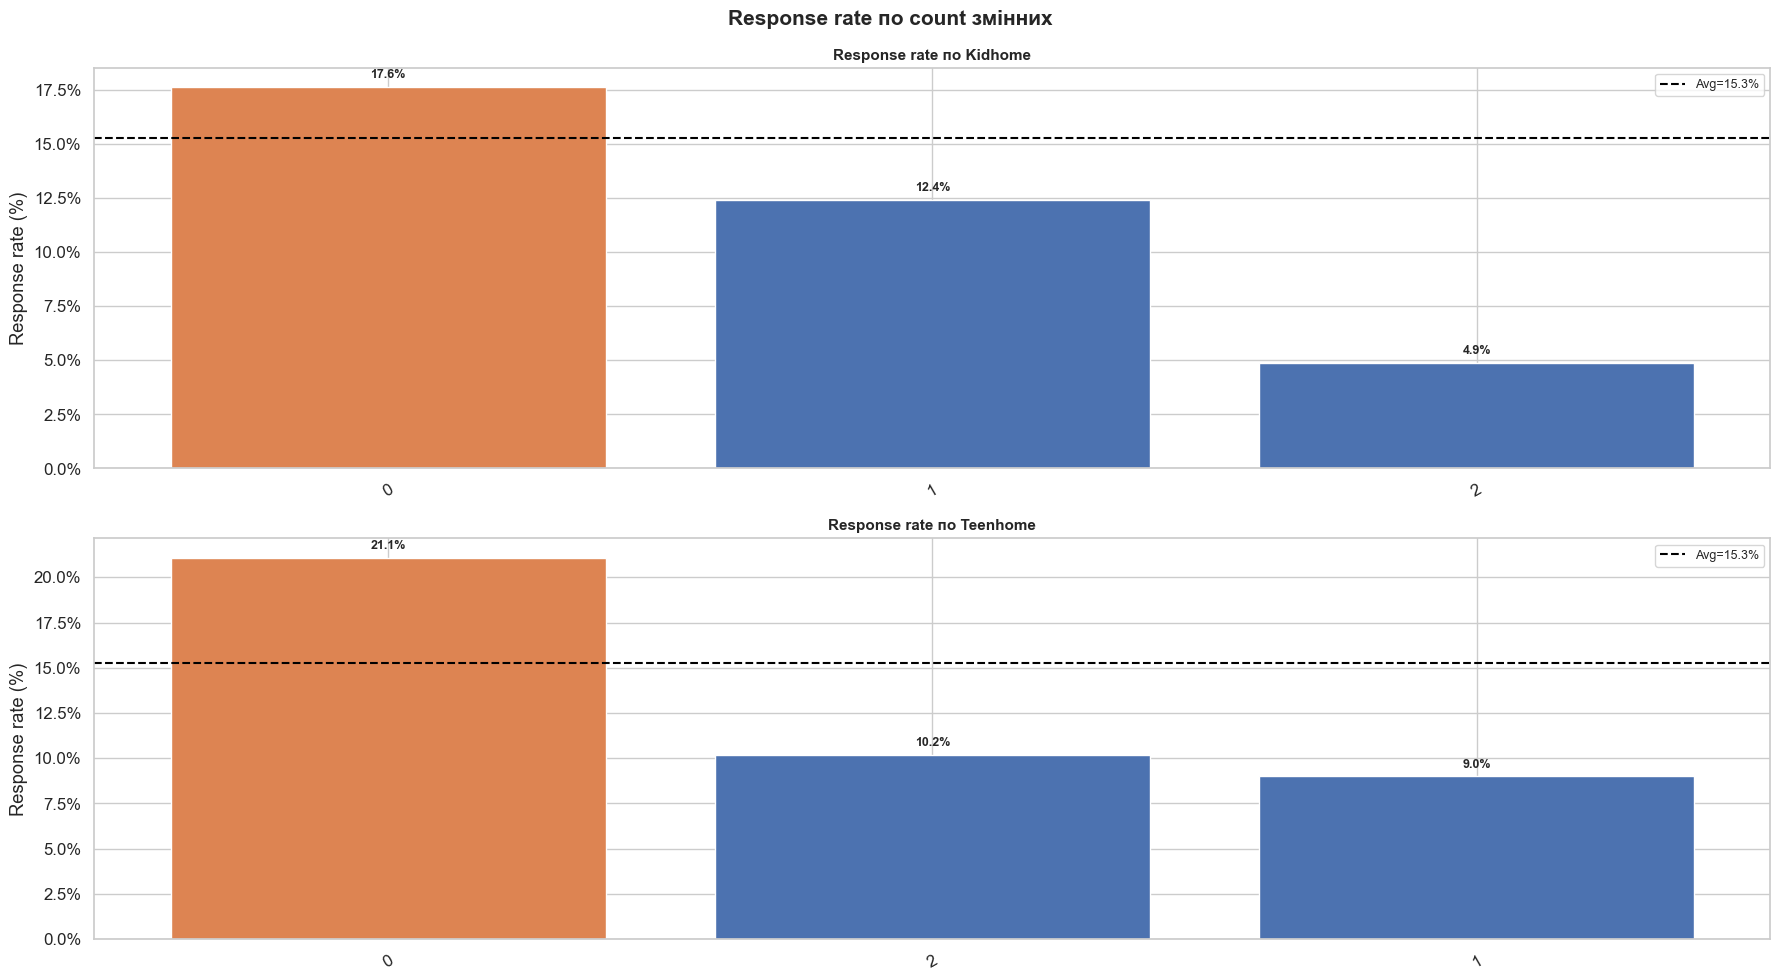

In [64]:
cat_target = ['Kidhome', 'Teenhome']

fig, axes = plt.subplots(2, 1, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_target):
    ax = axes[i]
    ct = df_clean.groupby(col)['Response'].mean().sort_values(ascending=False)
    colors = [PALETTE[1] if v > df_clean['Response'].mean() else PALETTE[0] for v in ct.values]
    bars = ax.bar(ct.index.astype(str), ct.values * 100, color=colors, edgecolor='white')
    ax.axhline(df_clean['Response'].mean() * 100, color='black',
               linestyle='--', linewidth=1.5, label=f'Avg={df_clean["Response"].mean()*100:.1f}%')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.3,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(f'Response rate по {col}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Response rate (%)')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('Response rate по count змінних', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Count-змінні: діти в домогосподарстві

### Kidhome (малі діти)

| Кількість дітей | Response rate |
|---|---|
| 0 | 17.6% ▲ |
| 1 | 12.4% ▼ |
| 2 | 4.9% ▼▼ |

### Teenhome (підлітки)

| Кількість підлітків | Response rate |
|---|---|
| 0 | 21.1% ▲ |
| 1 | 10.2% ▼ |
| 2 | 9.0% ▼▼ |

Обидві змінні показують один і той самий патерн: **наявність дітей суттєво знижує ймовірність відгуку**. Клієнти без дітей відгукуються майже вдвічі частіше. Це логічно — домогосподарства без дітей мають більше вільних коштів і більшу гнучкість у витратах.

---

### Channels vs Response

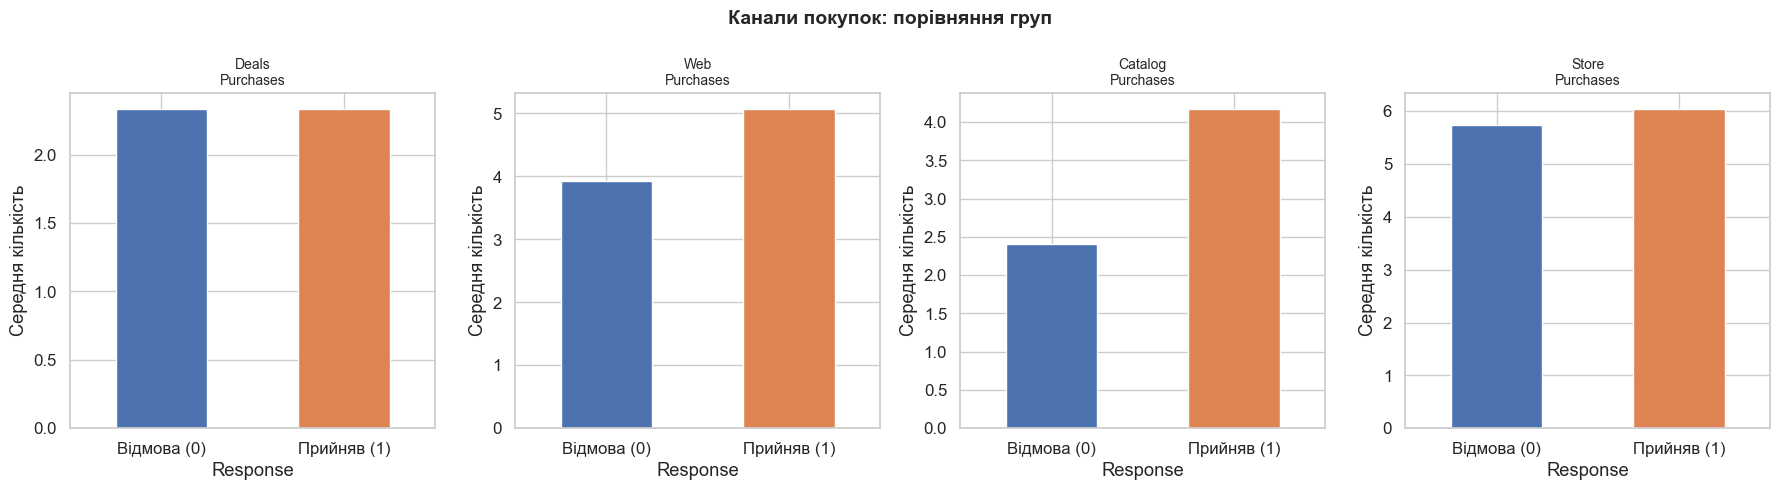

In [65]:
channel_cols = ['NumDealsPurchases', 'NumWebPurchases',
                'NumCatalogPurchases', 'NumStorePurchases']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(channel_cols):
    ax = axes[i]
    df_clean.groupby('Response')[col].mean().plot(
        kind='bar', ax=ax, color=PALETTE, edgecolor='white', rot=0
    )
    ax.set_title(col.replace('Num','').replace('Purchases','\nPurchases'), fontsize=10)
    ax.set_xlabel('Response')
    ax.set_ylabel('Середня кількість')
    ax.set_xticklabels(['Відмова (0)', 'Прийняв (1)'])

plt.suptitle('Канали покупок: порівняння груп', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Канали покупок

| Канал | Відмова (0) | Прийняв (1) | Різниця |
|---|---|---|---|
| Deals Purchases | ~2.5 | ~2.5 | Немає різниці |
| Web Purchases | ~4.0 | ~5.1 | +28% |
| Catalog Purchases | ~2.4 | ~4.2 | **+75%** — найбільша різниця |
| Store Purchases | ~5.9 | ~6.1 |  Мінімальна різниця |

Каталог — найсильніший сигнал серед каналів. Ті хто приймає пропозицію купують через каталог майже вдвічі частіше. Онлайн-покупки також дають помітний приріст. Магазин і знижки не розрізняють групи.

Ранжування всіх фіч для моделі

| Пріоритет | Фічі |
|---|---|
| Топ  | `Recency`, `MntWines`, `MntMeatProducts`, `NumCatalogPurchases`, `Marital_Status`, `Kidhome`, `Teenhome` |
| Середні | `Income`, `Education`, `MntGoldProds`, `NumWebPurchases`, `MntFruits`, `MntFishProducts`, `MntSweetProducts` |
| Слабкі  | `Age`, `NumWebVisitsMonth`, `NumDealsPurchases`, `NumStorePurchases`, `Complain` |

In [66]:
df_clean

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age
0,1826,1970,Graduation,Divorced,84835.00,0,0,2014-06-16,0,189,104,379,111,189,218,1,4,4,6,1,1,0,44
1,1,1961,Graduation,Single,57091.00,0,0,2014-06-15,0,464,5,64,7,0,37,1,7,3,7,5,1,0,53
2,10476,1958,Graduation,Married,67267.00,0,1,2014-05-13,0,134,11,59,15,2,30,1,3,2,5,2,0,0,56
3,1386,1967,Graduation,Together,32474.00,1,1,2014-11-05,0,10,0,1,0,0,0,1,1,0,2,7,0,0,47
4,5371,1989,Graduation,Single,21474.00,1,0,2014-08-04,0,6,16,24,11,0,34,2,3,1,2,7,1,0,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476.00,0,1,2013-07-03,99,372,18,126,47,48,78,2,5,2,11,4,0,0,38
2236,5263,1977,2n Cycle,Married,31056.00,1,0,2013-01-22,99,5,10,13,3,8,16,1,1,0,3,8,0,0,37
2237,22,1976,Graduation,Divorced,46310.00,1,0,2012-03-12,99,185,2,88,15,5,14,2,6,1,5,8,0,0,38
2238,528,1978,Graduation,Married,65819.00,0,0,2012-11-29,99,267,38,701,149,165,63,1,5,4,10,3,0,0,36


In [67]:

cols_all = [c for c in df_clean.columns if c != "Id"]
print("Колонки для аналізу:", cols_all)

cat_cols = df_clean.select_dtypes(include=["object","category"]).columns.tolist()

cat_cols = [c for c in cat_cols if c in cols_all]
num_cols = [c for c in cols_all if c not in cat_cols]
print("Категоріальні:", cat_cols)
print("Числові:", num_cols)

education_order = {
    "Basic": 0,
    "2n Cycle": 1,
    "Graduation": 2,
    "Master": 3,
    "PhD": 4
}

df_clean["Education"] = df_clean["Education"].map(education_order)

print("=== Education mapping ===")
for k, v in education_order.items():
    print(f"{v} -> {k}")

marital_cat = df_clean["Marital_Status"].astype("category")

df_clean["Marital_Status"] = marital_cat.cat.codes

print("\n=== Marital_Status mapping ===")
for code, category in enumerate(marital_cat.cat.categories):
    print(f"{code} -> {category}")

Колонки для аналізу: ['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Response', 'Complain', 'Age']
Категоріальні: ['Education', 'Marital_Status']
Числові: ['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Response', 'Complain', 'Age']
=== Education mapping ===
0 -> Basic
1 -> 2n Cycle
2 -> Graduation
3 -> Master
4 -> PhD

=== Marital_Status mapping ===
0 -> Divorced
1 -> Married
2 -> Single
3 -> Together
4 -> Widow


In [68]:
df_clean

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age
0,1826,1970,2,0,84835.00,0,0,2014-06-16,0,189,104,379,111,189,218,1,4,4,6,1,1,0,44
1,1,1961,2,2,57091.00,0,0,2014-06-15,0,464,5,64,7,0,37,1,7,3,7,5,1,0,53
2,10476,1958,2,1,67267.00,0,1,2014-05-13,0,134,11,59,15,2,30,1,3,2,5,2,0,0,56
3,1386,1967,2,3,32474.00,1,1,2014-11-05,0,10,0,1,0,0,0,1,1,0,2,7,0,0,47
4,5371,1989,2,2,21474.00,1,0,2014-08-04,0,6,16,24,11,0,34,2,3,1,2,7,1,0,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,4,0,66476.00,0,1,2013-07-03,99,372,18,126,47,48,78,2,5,2,11,4,0,0,38
2236,5263,1977,1,1,31056.00,1,0,2013-01-22,99,5,10,13,3,8,16,1,1,0,3,8,0,0,37
2237,22,1976,2,0,46310.00,1,0,2012-03-12,99,185,2,88,15,5,14,2,6,1,5,8,0,0,38
2238,528,1978,2,1,65819.00,0,0,2012-11-29,99,267,38,701,149,165,63,1,5,4,10,3,0,0,36


### Кореляційний аналіз

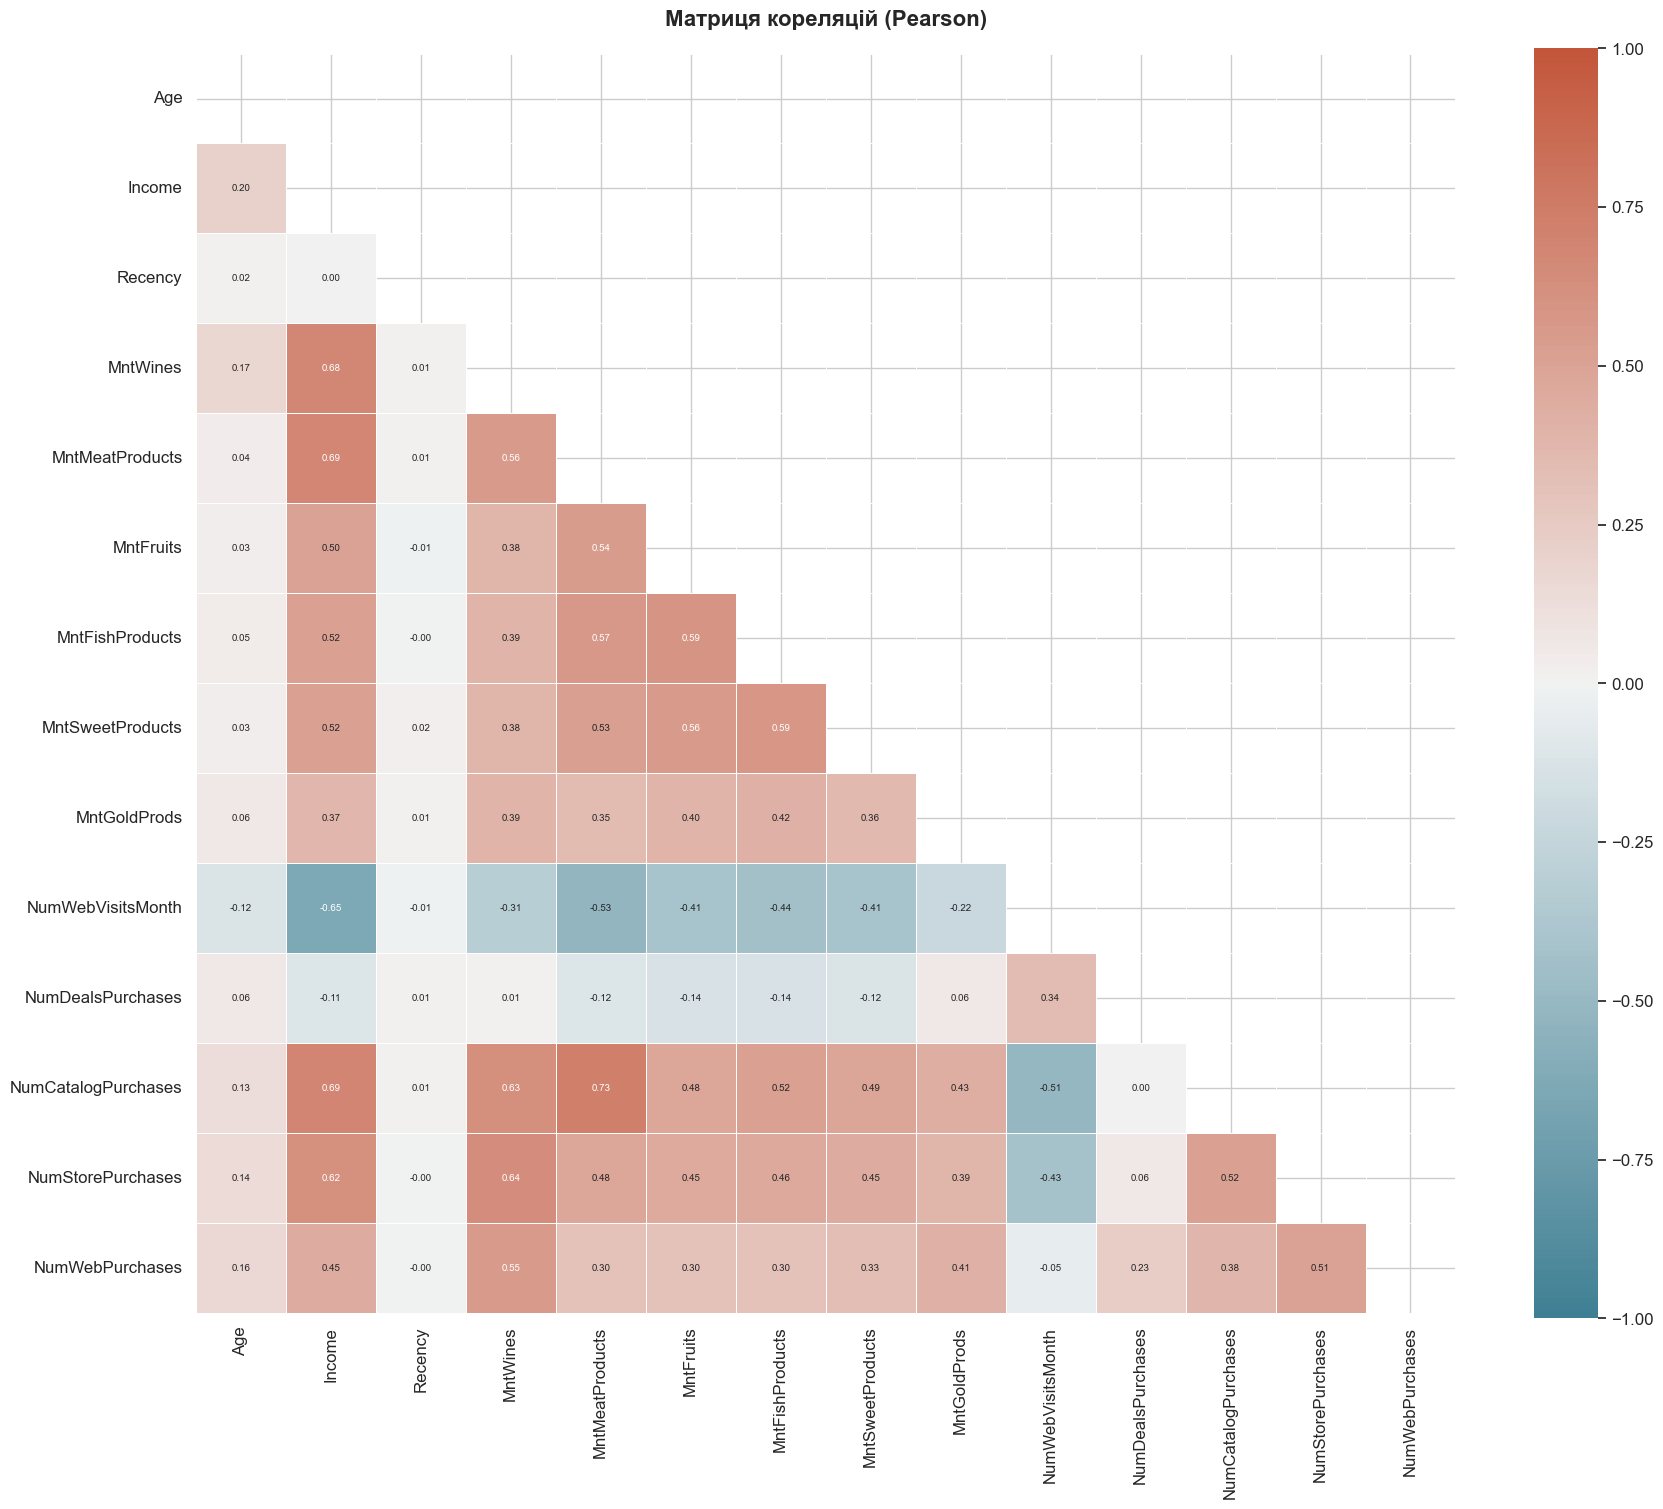

In [69]:
corr_cols = ['Age', 'Income', 'Recency',
            'MntWines', 'MntMeatProducts', 'MntFruits',
            'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
            'NumWebVisitsMonth', 'NumDealsPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebPurchases']

corr_matrix = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, center=0,
            annot=True, fmt='.2f', linewidths=.5,
            annot_kws={'size': 7}, ax=ax,
            vmin=-1, vmax=1, square=True)
ax.set_title('Матриця кореляцій (Pearson)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [70]:
high_corr = []
for i in range(len(corr_cols)-1):
    for j in range(i+1, len(corr_cols)-1):
        c = corr_matrix.iloc[i, j]
        if abs(c) > 0.7:
            high_corr.append({'Ознака 1': corr_cols[i],
                              'Ознака 2': corr_cols[j],
                              'Correlation': round(c, 3)})

hc_df = pd.DataFrame(high_corr).sort_values('Correlation', key=abs, ascending=False)
print('Пари ознак з |correlation| > 0.7 (потенційна мультиколінеарність):')
print(hc_df.to_string(index=False))

Пари ознак з |correlation| > 0.7 (потенційна мультиколінеарність):
       Ознака 1            Ознака 2  Correlation
MntMeatProducts NumCatalogPurchases         0.73


Портрет клієнта, який прийме пропозицію

| Характеристика | Профіль | Обґрунтування |
|---|---|---|
| **Дохід** | Вищий за середній (~70–80k+) | d=0.44, помаранчева крива зміщена вправо |
| **Освіта** | PhD або Master | Response rate 20.6% / 15.9% vs avg 15.3% |
| **Сімейний статус** | Самотній, вдівець або розлучений | Widow 25.7%, Single 23.1% — найвища конверсія |
| **Діти** | Немає малих дітей | 0 дітей → 17.6% vs 2 дітей → 4.9% |
| **Підлітки** | Немає підлітків | 0 підлітків → 21.1% vs 1+ → ~10% |
| **Активність** | Купував нещодавно | d=-0.59, найсильніша фіча — низький Recency |
| **Продукти** | Багато витрачає на вино та м'ясо | d=0.61 / d=0.60 — топ предиктори |
| **Канал покупок** | Активно замовляє через каталог | Прийняв: ~4.2 vs Відмовив: ~2.4 (+75%) |
| **Онлайн** | Купує через сайт компанії | Прийняв: ~5.1 vs Відмовив: ~4.0 (+28%) |
| **Акції** | Не орієнтований на знижки | NumDealsPurchases: d=0.00, нульова різниця між групами |


Це **забезпечений освічений одинак без дітей**, який нещодавно робив покупки і демонструє преміальний стиль споживання - витрачає значні суми на вино та м'ясо. Він звик замовляти через каталог і онлайн, не орієнтується на акційні ціни (кількість покупок зі знижками однакова в обох групах), а цінує якість і зручність. Через відсутність сім'ї самостійно розпоряджається бюджетом і більш відкритий до нових пропозицій.


In [71]:
from scipy import stats
from math import ceil


def detect_outliers_zscore(df, cols=None, thresh=3.0, abs_z=True, dropna=True):
    numeric = df[cols].astype(float)

    z = (numeric - numeric.mean()) / numeric.std(ddof=0)
    if abs_z:
        z = z.abs()
    mask = z > thresh
    if dropna:
        mask = mask.fillna(False)
    return mask, z  # mask: bool DF, z: numeric z-scores DF


def outlier_summary(mask):
    per_col = mask.sum().sort_values(ascending=False)
    total_any = mask.any(axis=1).sum()
    total_all = (mask.sum(axis=1) == mask.shape[1]).sum() if mask.shape[1] > 0 else 0
    return {'per_column': per_col, 'total_any': int(total_any), 'total_all': int(total_all)}


def show_top_outliers(df, mask, zscores, top_n=20, id_col='Id'):
    max_z = zscores.max(axis=1).abs()

    rows_with = mask.any(axis=1)
    candidates = df.loc[rows_with].copy()
    candidates['_max_z'] = max_z[rows_with]

    def columns_over_thresh(r):
        return mask.columns[r.values].tolist()

    candidates['_outlier_cols'] = mask[rows_with].apply(lambda r: mask.columns[r.values].tolist(), axis=1)
    out = candidates.sort_values('_max_z', ascending=False).head(top_n)
    cols_to_show = [id_col, '_max_z', '_outlier_cols'] + list(mask.columns)
    existing = [c for c in cols_to_show if c in out.columns]
    return out[existing]


def drop_outliers(df, mask, how='any'):
    """
    Видалити аутлаєри:
    - how='any'  -> видаляє рядок якщо будь-яка колонка помічена
    - how='all'  -> видаляє рядок якщо ВСІ колонки помічені
    Повертає новий DataFrame.
    """
    if how == 'any':
        idx_to_drop = mask.any(axis=1)
    elif how == 'all':
        idx_to_drop = mask.all(axis=1)
    else:
        raise ValueError("how must be 'any' or 'all'")
    print(f"Видаляється {idx_to_drop.sum()} рядків (how={how}).")
    return df.loc[~idx_to_drop].copy()


def plot_outlier_summary(mask, ax=None, title="Outliers per column"):
    counts = mask.sum().sort_values(ascending=False)
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, max(4, len(counts)*0.25)))
    counts.plot.bar(ax=ax)
    ax.set_ylabel("Count of outliers")
    ax.set_title(title)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    return ax


def visualize_outliers(df, mask, zscores, cols=None, top_n=20, id_col='Id',
                       max_cols_per_page=12, figsize_per_col=(6,3)):
    if cols is None:
        cols = list(mask.columns)
    else:
        cols = [c for c in cols if c in mask.columns]

    plt.figure(figsize=(10,4))
    plot_outlier_summary(mask)
    plt.show()

    n = len(cols)
    if n == 0:
        print("No columns to plot.")
        return

    cols_per_page = max_cols_per_page
    pages = ceil(n / cols_per_page)

    for p in range(pages):
        page_cols = cols[p*cols_per_page:(p+1)*cols_per_page]
        m = len(page_cols)
        cols_in_row = min(3, m)
        rows = ceil(m / cols_in_row)
        fig, axes = plt.subplots(rows*2, cols_in_row, figsize=(cols_in_row * figsize_per_col[0],
                                                               rows * 2 * figsize_per_col[1]))
        if isinstance(axes, plt.Axes):
            axes = np.array([[axes]])
        axes = axes.reshape(rows*2, cols_in_row)
        for i, col in enumerate(page_cols):
            row_idx = i // cols_in_row
            col_idx = i % cols_in_row
            ax_hist = axes[row_idx*2, col_idx]
            ax_box = axes[row_idx*2 + 1, col_idx]

            series = df[col].dropna().astype(float)
            if series.empty:
                ax_hist.text(0.5,0.5,"no data", ha='center', va='center')
                ax_box.text(0.5,0.5,"no data", ha='center', va='center')
                continue

            # histogram + KDE
            vals = series.values
            ax_hist.hist(vals, bins=40, density=True, alpha=0.6)
            try:
                kde = stats.gaussian_kde(vals)
                xs = np.linspace(vals.min(), vals.max(), 200)
                ax_hist.plot(xs, kde(xs))
            except Exception:
                pass

            # mean and std lines
            mu, sigma = np.nanmean(vals), np.nanstd(vals)
            ax_hist.axvline(mu, linestyle='--', linewidth=1)
            ax_hist.axvline(mu + 3*sigma, linestyle=':', linewidth=1)
            ax_hist.axvline(mu - 3*sigma, linestyle=':', linewidth=1)

            # rug for outliers: понизимо y для відміток
            out_idx = mask[col] == True
            out_vals = df.loc[out_idx, col].dropna().astype(float).values
            if len(out_vals) > 0:
                y_rug = np.full_like(out_vals, -0.01 * max(1.0, ax_hist.get_ylim()[1]))
                # рисуємо як маленькі трикутники нижче осі
                ax_hist.scatter(out_vals, y_rug, marker='v', s=20)

            ax_hist.set_title(f"{col} (n={len(vals)})")
            ax_hist.grid(axis='y', linestyle='--', alpha=0.3)

            # boxplot (по горизонталі)
            ax_box.boxplot(vals, vert=False, showfliers=False)
            ax_box.set_xlim(ax_hist.get_xlim())

            # overlay outliers on boxplot
            if len(out_vals) > 0:
                # place them near y=1 (since boxplot has single row)
                jitter = (np.random.rand(len(out_vals)) - 0.5) * 0.05
                ax_box.scatter(out_vals, np.ones_like(out_vals) + jitter, marker='o', s=20)
            ax_box.set_yticks([])

        total_axes = rows*2*cols_in_row
        for idx in range(m, total_axes//2 * 2):
            r = idx // cols_in_row
            c = idx % cols_in_row
            if (r*cols_in_row + c) >= m and (r % 2 == 0):
                axes[r, c].axis('off')
                if r+1 < axes.shape[0]:
                    axes[r+1, c].axis('off')

        plt.tight_layout()
        plt.show()

    top_df = show_top_outliers(df, mask, zscores, top_n=top_n, id_col=id_col)
    if top_df.shape[0] == 0:
        print("No top outliers to plot.")
        return

    numeric_cols = [c for c in mask.columns if pd.api.types.is_numeric_dtype(df[c])]
    if len(numeric_cols) < 2:
        print("Not enough numeric columns to show pairwise scatter.")
        return
    n_pair_cols = min(6, len(numeric_cols))
    pair_cols = numeric_cols[:n_pair_cols]

    k = len(pair_cols)
    fig, axes = plt.subplots(k, k, figsize=(3*k, 3*k))
    for i, ci in enumerate(pair_cols):
        for j, cj in enumerate(pair_cols):
            ax = axes[i, j]
            if i == j:
                ax.hist(df[ci].dropna().astype(float), bins=30)
                ax.set_xlabel(ci)
            else:
                ax.scatter(df[cj], df[ci], s=5, alpha=0.4)
                ax.scatter(top_df[cj], top_df[ci], s=40, edgecolor='k')
                if j == 0:
                    ax.set_ylabel(ci)
                if i == k-1:
                    ax.set_xlabel(cj)
    plt.suptitle(f"Pairwise scatter of top-{top_n} outlier rows highlighted")
    plt.tight_layout()
    plt.show()

Аутлаєри по колонках (кількість):
MntFruits              60
MntSweetProducts       54
MntFishProducts        52
MntGoldProds           42
MntMeatProducts        34
NumDealsPurchases      29
Income_log1p           29
MntWines               13
NumWebVisitsMonth       9
NumCatalogPurchases     4
NumWebPurchases         3
Recency                 0
Year_Birth              0
NumStorePurchases       0
dtype: int64
Рядків з ≥1 аутлаєром: 252
Рядків з аутлаєрами у ВСІХ перевірених колонках: 0


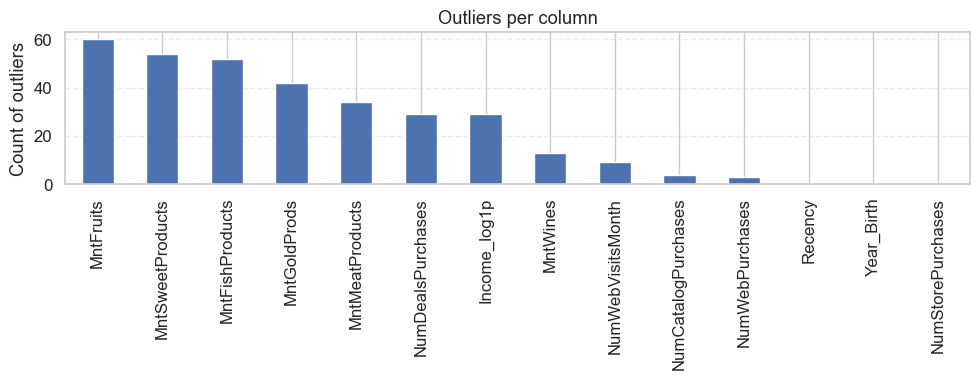

<Figure size 1000x400 with 0 Axes>

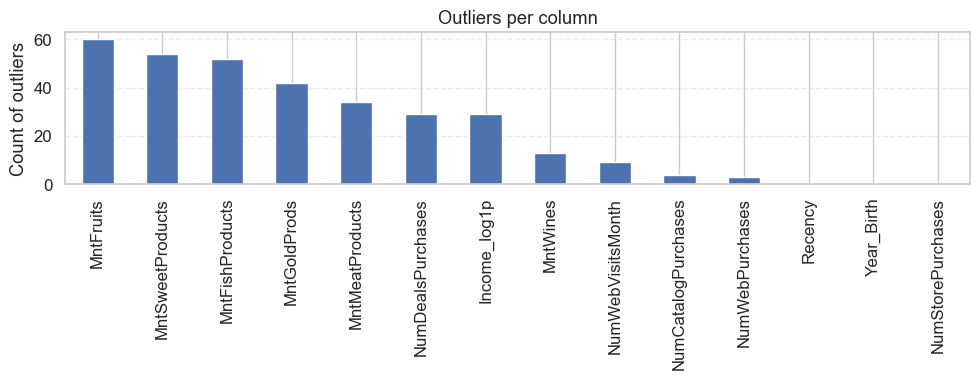

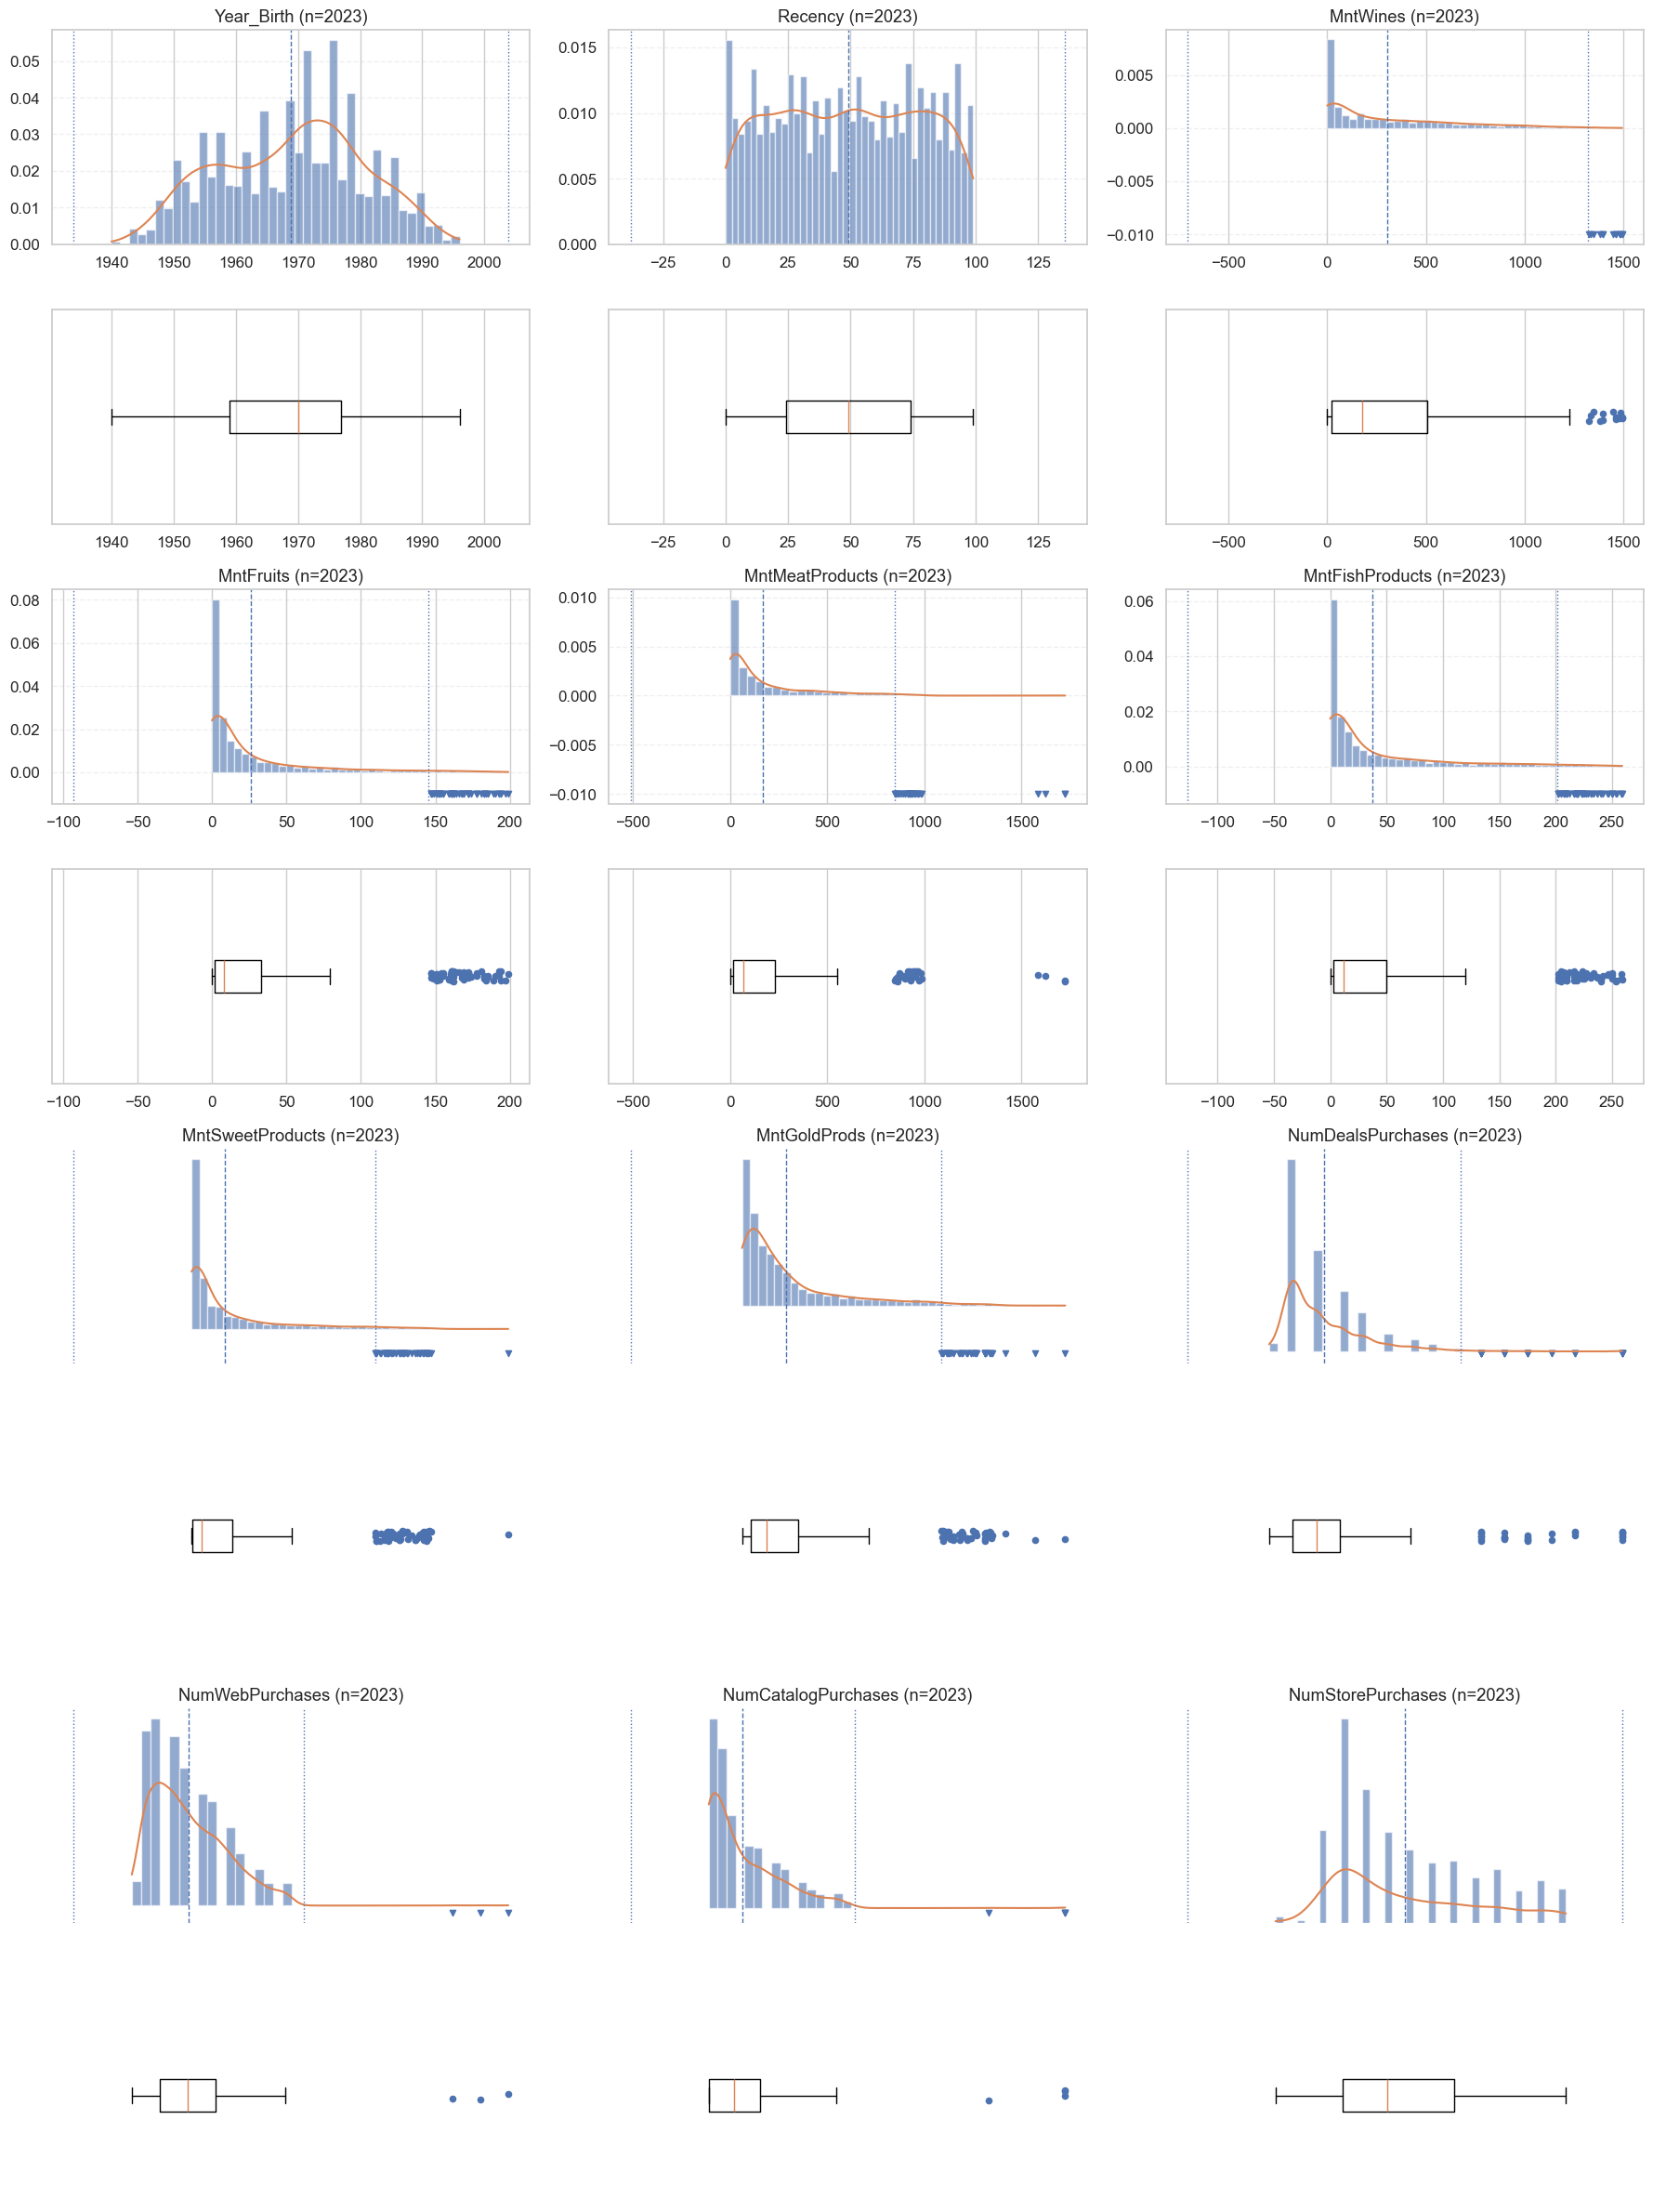

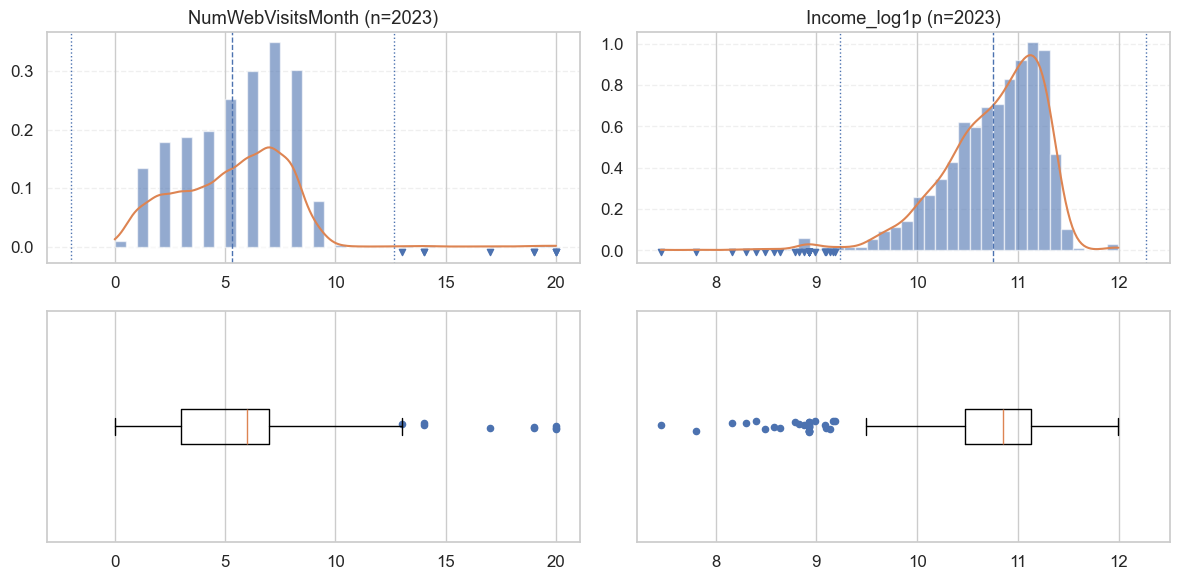

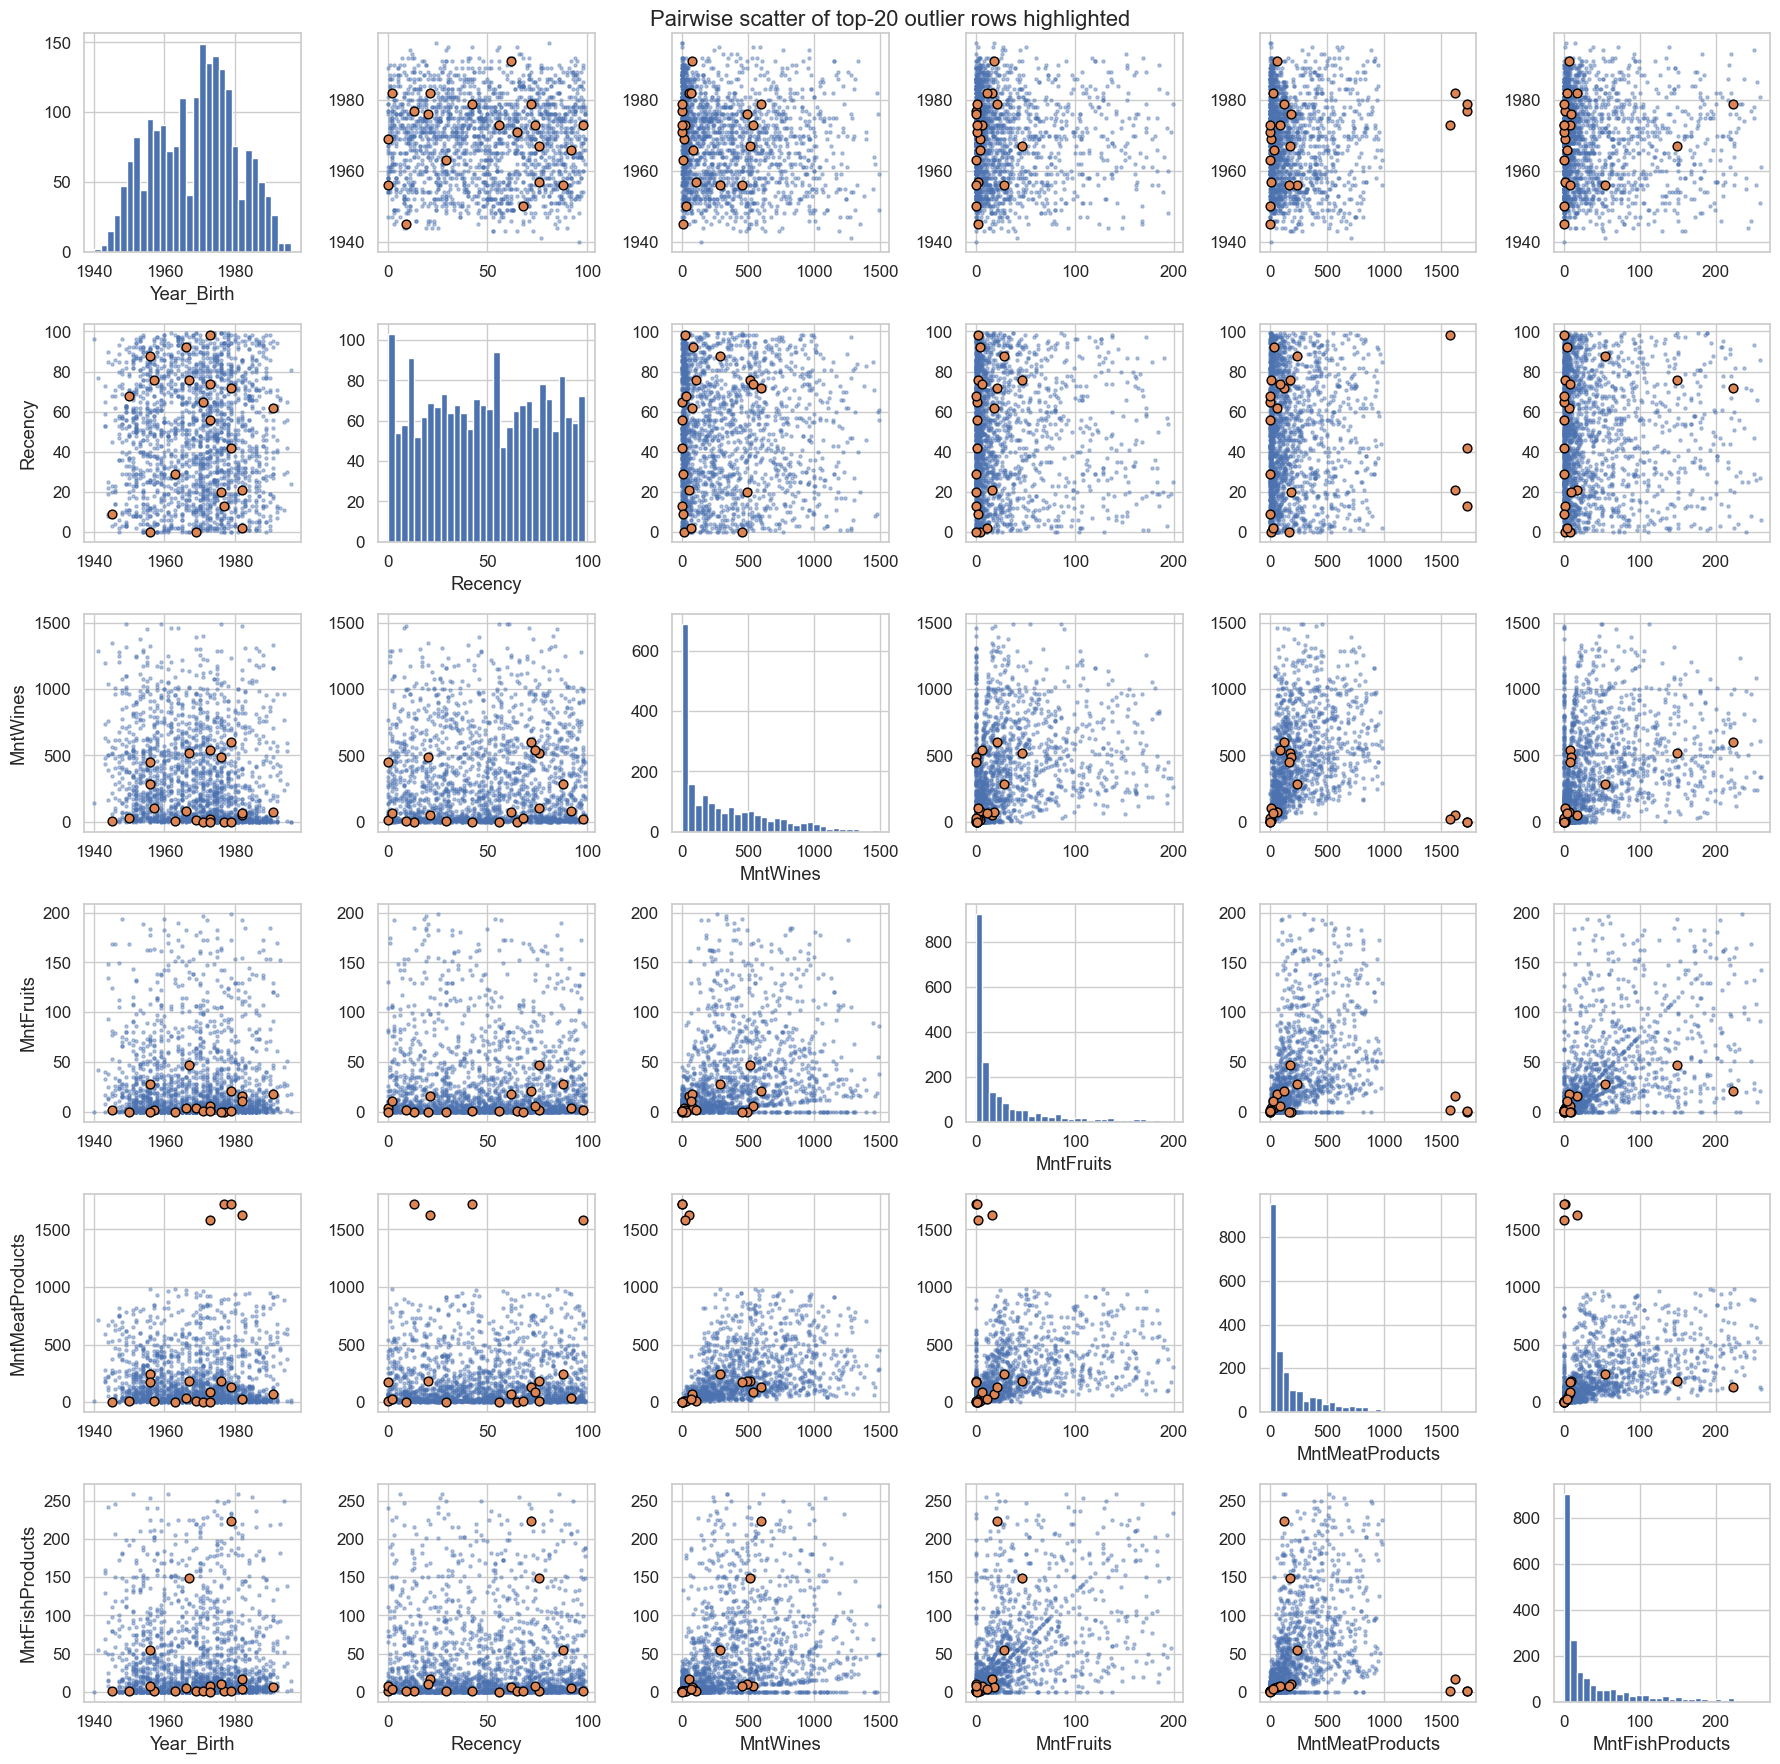

In [72]:
numeric_columns = [
    "Year_Birth",
    "Recency",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "Income_log1p"
]

df_clean['Income_log1p'] = np.log1p(df_clean['Income'].fillna(0))

mask, z = detect_outliers_zscore(df_clean, cols=numeric_columns, thresh=3.0)
summary = outlier_summary(mask)
print("Аутлаєри по колонках (кількість):")
print(summary['per_column'])
print(f"Рядків з ≥1 аутлаєром: {summary['total_any']}")
print(f"Рядків з аутлаєрами у ВСІХ перевірених колонках: {summary['total_all']}")

#top = show_top_outliers(df_clean, mask, z, top_n=20, id_col='Id')
#top

#df_clean = drop_outliers(df, mask, how='any')
#df_clean.to_csv("data_clean.csv", index=False)

plot_outlier_summary(mask)
visualize_outliers(df_clean, mask, z, cols=numeric_columns, top_n=20, id_col='Id')

In [73]:
df_clean['Income'].skew()

np.float64(0.36748738091383504)

In [74]:
df_clean['Income_log1p'].skew()

np.float64(-1.2938560730037618)

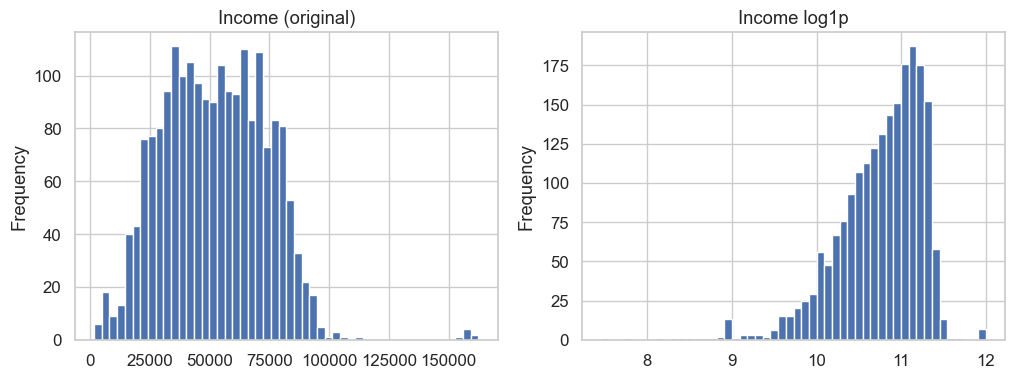

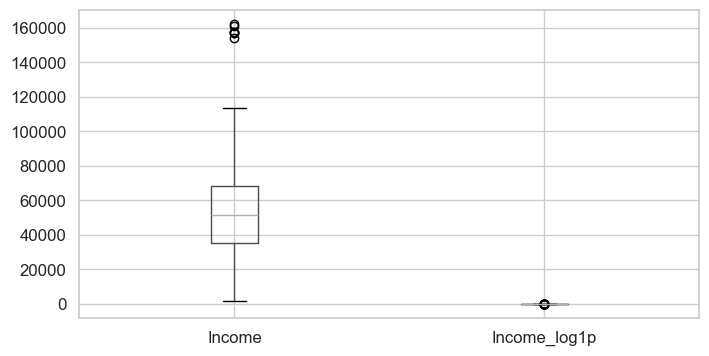

In [75]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
df_clean['Income'].plot.hist(ax=axes[0], bins=50, title='Income (original)')
df_clean['Income_log1p'].plot.hist(ax=axes[1], bins=50, title='Income log1p')
plt.show()

df_clean[['Income','Income_log1p']].boxplot(figsize=(8,4))
plt.show()

In [76]:
df_clean

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age,Income_log1p
0,1826,1970,2,0,84835.00,0,0,2014-06-16,0,189,104,379,111,189,218,1,4,4,6,1,1,0,44,11.35
1,1,1961,2,2,57091.00,0,0,2014-06-15,0,464,5,64,7,0,37,1,7,3,7,5,1,0,53,10.95
2,10476,1958,2,1,67267.00,0,1,2014-05-13,0,134,11,59,15,2,30,1,3,2,5,2,0,0,56,11.12
3,1386,1967,2,3,32474.00,1,1,2014-11-05,0,10,0,1,0,0,0,1,1,0,2,7,0,0,47,10.39
4,5371,1989,2,2,21474.00,1,0,2014-08-04,0,6,16,24,11,0,34,2,3,1,2,7,1,0,25,9.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,4,0,66476.00,0,1,2013-07-03,99,372,18,126,47,48,78,2,5,2,11,4,0,0,38,11.10
2236,5263,1977,1,1,31056.00,1,0,2013-01-22,99,5,10,13,3,8,16,1,1,0,3,8,0,0,37,10.34
2237,22,1976,2,0,46310.00,1,0,2012-03-12,99,185,2,88,15,5,14,2,6,1,5,8,0,0,38,10.74
2238,528,1978,2,1,65819.00,0,0,2012-11-29,99,267,38,701,149,165,63,1,5,4,10,3,0,0,36,11.09


           count   mean    std  min    25%    50%    75%     max
Response                                                        
0        1714.00 494.53 228.53 0.00 319.00 492.00 662.00 1063.00
1         309.00 606.03 231.89 4.00 429.00 642.00 788.00 1063.00


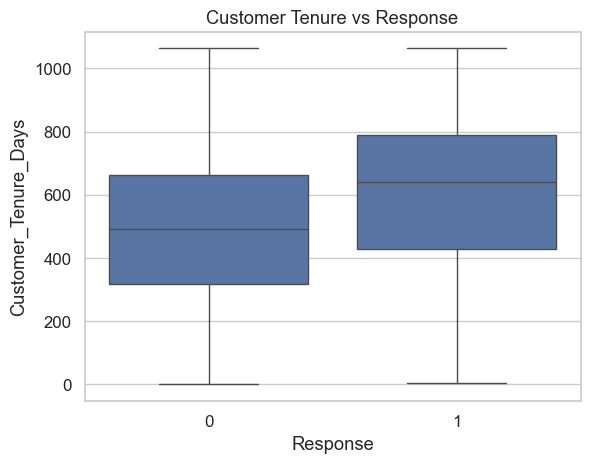

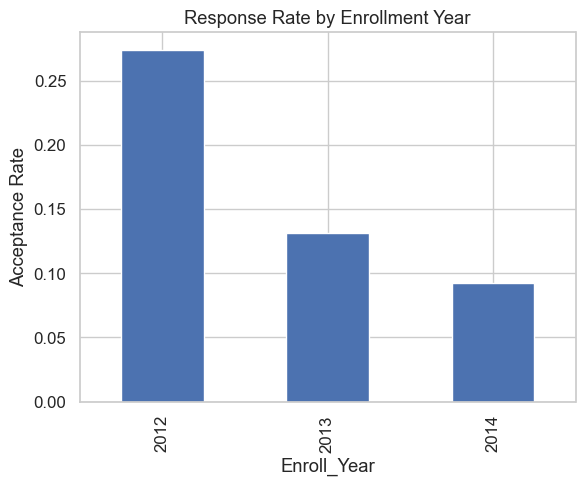

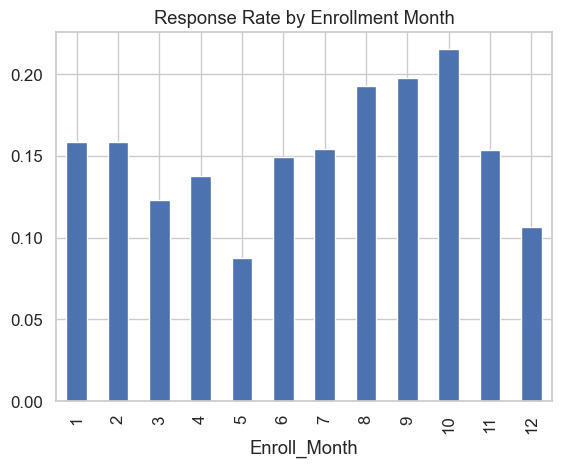

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_clean['Dt_Customer'] = pd.to_datetime(df_clean['Dt_Customer'])

# --- Feature engineering ---
# Опорна дата — максимальна в датасеті (або дата зрізу)
reference_date = df_clean['Dt_Customer'].max()

df_clean['Customer_Tenure_Days'] = (reference_date - df_clean['Dt_Customer']).dt.days
df_clean['Enroll_Year']    = df_clean['Dt_Customer'].dt.year
df_clean['Enroll_Month']   = df_clean['Dt_Customer'].dt.month
df_clean['Enroll_Quarter'] = df_clean['Dt_Customer'].dt.quarter

# --- Перевірка кореляції з таргетом ---
print(df_clean.groupby('Response')['Customer_Tenure_Days'].describe())

# Boxplot: tenure vs response
sns.boxplot(x='Response', y='Customer_Tenure_Days', data=df_clean)
plt.title('Customer Tenure vs Response')
plt.show()

# Conversion rate по роках вступу
df_clean.groupby('Enroll_Year')['Response'].mean().plot(kind='bar')
plt.title('Response Rate by Enrollment Year')
plt.ylabel('Acceptance Rate')
plt.show()

# Conversion rate по місяцях
df_clean.groupby('Enroll_Month')['Response'].mean().plot(kind='bar')
plt.title('Response Rate by Enrollment Month')
plt.show()

In [78]:
from scipy import stats

accepted     = df_clean[df_clean['Response'] == 1]['Customer_Tenure_Days']
not_accepted = df_clean[df_clean['Response'] == 0]['Customer_Tenure_Days']

t_stat, p_val = stats.ttest_ind(accepted, not_accepted)
print(f"T-test: t={t_stat:.3f}, p={p_val:.4f}")

# Якщо p < 0.05 — різниця статистично значуща → залишаємо

T-test: t=7.876, p=0.0000


In [79]:
df_clean['Is_HighSeason_Enroll'] = df_clean['Enroll_Month'].isin([8, 9, 10, 1, 2]).astype(int)

accepted     = df_clean[df_clean['Response'] == 1]['Is_HighSeason_Enroll']
not_accepted = df_clean[df_clean['Response'] == 0]['Is_HighSeason_Enroll']

t_stat, p_val = stats.ttest_ind(accepted, not_accepted)
print(f"T-test: t={t_stat:.3f}, p={p_val:.4f}")

# Якщо p < 0.05 — різниця статистично значуща → залишаємо

T-test: t=3.499, p=0.0005
